# BTXRD Portion 2 + Portion 3 — **FIXED v3 all-class baselines + BTX-TrustNet-v2**

**Purpose:** this notebook fixes the previous tumor-only mistake and reruns Portion 2/3 as a true **3-class** medical-imaging experiment:

```text
normal vs benign tumor vs malignant tumor
```

## Critical correction v3

This version also recovers normal radiographs from raw `BTXRD/images` when the Portion-1 tables are tumor-only. The earlier Portion 2/3 notebook used only `gold_multitask` rows. Those rows are tumor cases only, so the normal class disappeared. This fixed notebook builds the final training table as:

```text
all valid normal radiographs
+
gold benign tumor radiographs with masks
+
gold malignant tumor radiographs with masks
```

## Plan reminder

| Portion | What this notebook does |
|---:|---|
| **2** | Corrected all-class baseline system: metadata-only + image-only deep baselines |
| **3** | Proposed **BTX-TrustNet-v2** architecture: lesion-mask guidance, metadata fusion, hierarchical diagnosis, center-adversarial learning, evidential uncertainty, and XAI alignment |

## Main final data table produced

```text
/kaggle/working/BTXRD_Portion2_3_FIXED/tables/btxrd_final_gold_plus_normals.csv
```

## Kaggle input expected

Your Portion-1 notebook output is expected here:

```python
/kaggle/input/notebooks/koushikrudra/btxrd-p1
```

Keep the original BTXRD image dataset attached as a Kaggle input as well, because Portion-1 usually contains cleaned tables and masks, while the raw image files may remain in the original BTXRD dataset input.

In [1]:
# ============================================================
# 0. Imports, reproducibility, and journal-style configuration
# ============================================================
import os
import re
import json
import math
import time
import shutil
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageEnhance, ImageDraw, UnidentifiedImageError
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

warnings.filterwarnings("ignore")
Image.MAX_IMAGE_PIXELS = None

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

try:
    from IPython.display import display, Markdown
except Exception:
    display = print
    Markdown = lambda x: x

try:
    import cv2
except Exception:
    cv2 = None

try:
    from scipy import ndimage as ndi
except Exception:
    ndi = None

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    cohen_kappa_score,
    brier_score_loss,
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

try:
    import torchvision
    import torchvision.models as tv_models
except Exception as e:
    raise RuntimeError("torchvision is required for this notebook.") from e

try:
    from torchvision.transforms import functional as TF
except Exception:
    TF = None

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# -----------------------------
# Paths
# -----------------------------
PORTION1_INPUT = Path("/kaggle/input/notebooks/koushikrudra/btxrd-p1")
OUT_DIR = Path("/kaggle/working/BTXRD_Portion2_3_FIXED") if Path("/kaggle/working").exists() else Path.cwd() / "BTXRD_Portion2_3_FIXED"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
CKPT_DIR = OUT_DIR / "checkpoints"
REPORT_DIR = OUT_DIR / "reports"
PRED_DIR = OUT_DIR / "predictions"
for d in [OUT_DIR, TABLE_DIR, FIG_DIR, CKPT_DIR, REPORT_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Label order used everywhere
# -----------------------------
LABEL_ORDER = ["normal", "benign", "malignant"]
LABEL_TO_ID = {"normal": 0, "benign": 1, "malignant": 2}
ID_TO_LABEL = {v: k for k, v in LABEL_TO_ID.items()}
CLASS_COLORS = {
    "normal": "#4C78A8",
    "benign": "#F58518",
    "malignant": "#E45756",
    "tumor": "#A23B72",
    "unknown": "#9E9E9E",
}

# Journal-style plotting.
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.6,
})

print("Output directory:", OUT_DIR)
print("Portion-1 input root:", PORTION1_INPUT, "exists=", PORTION1_INPUT.exists())

Device: cuda
GPU: Tesla T4
Output directory: /kaggle/working/BTXRD_Portion2_3_FIXED
Portion-1 input root: /kaggle/input/notebooks/koushikrudra/btxrd-p1 exists= True


## 1. Training mode

The notebook is ready for a final journal-style run, but training time depends on Kaggle GPU type. Use:

| Mode | Intended use | Typical setting |
|---|---|---|
| `smoke` | verify paths and code quickly | 1 epoch, small sample |
| `main` | strong development result | 8–15 epochs |
| `publication` | best result attempt | 25+ epochs, ensemble later |

For your objective, keep `RUN_MODE = "publication"` when GPU is available. The notebook automatically reduces workload if no GPU is detected.

In [2]:
# ============================================================
# 1. Config
# ============================================================
RUN_MODE = "publication"   # "smoke", "main", or "publication"

if DEVICE.type != "cuda":
    RUN_MODE = "smoke"
    print("No GPU detected. RUN_MODE changed to 'smoke' for safety.")

@dataclass
class CFG:
    # 448 is a strong balance for Kaggle T4/P100. Use 512 only on larger GPUs.
    img_size: int = 448
    batch_size: int = 4

    # Kaggle can warn or hang with forked DataLoader workers in some notebook states.
    # Fixed according to the previous run feedback.
    num_workers: int = 0

    # Baseline and TrustNet training.
    baseline_epochs: int = 10
    trustnet_stage1_epochs: int = 6
    trustnet_stage2_epochs: int = 8
    trustnet_stage3_epochs: int = 14

    # Learning rates.
    lr_backbone: float = 1e-5
    lr_head: float = 2e-4
    weight_decay: float = 1e-4
    grad_accum_steps: int = 1

    # Training options.
    amp: bool = True
    use_weighted_sampler: bool = True
    max_train_samples: int | None = None
    max_val_samples: int | None = None
    max_test_samples: int | None = None

    # Baselines. Publication mode adds stronger models.
    baseline_models: tuple = ("efficientnet_b0", "convnext_tiny")

    # Proposed architecture.
    preferred_backbone: str = "auto_dinov2_then_convnext"  # fallback-safe
    use_dinov2_lora: bool = True
    use_pretrained_torchvision: bool = True
    use_metadata: bool = True
    use_center_adversarial: bool = True
    use_attention_xai_head: bool = True
    use_mask_derived_box_for_detection: bool = True
    allow_horizontal_flip: bool = True

    # Model selection weights: optimized for Q1-style clinical usefulness, not plain accuracy.
    malignant_priority: float = 0.42
    macro_f1_priority: float = 0.28
    balanced_acc_priority: float = 0.20
    calibration_priority: float = 0.10

cfg = CFG()

if RUN_MODE == "smoke":
    cfg.img_size = 320
    cfg.batch_size = 2
    cfg.baseline_epochs = 1
    cfg.trustnet_stage1_epochs = 1
    cfg.trustnet_stage2_epochs = 1
    cfg.trustnet_stage3_epochs = 1
    cfg.max_train_samples = 120
    cfg.max_val_samples = 60
    cfg.max_test_samples = 60
    cfg.baseline_models = ("efficientnet_b0",)
elif RUN_MODE == "main":
    cfg.img_size = 384
    cfg.batch_size = 4
    cfg.baseline_epochs = 8
    cfg.trustnet_stage1_epochs = 4
    cfg.trustnet_stage2_epochs = 6
    cfg.trustnet_stage3_epochs = 10
    cfg.baseline_models = ("efficientnet_b0", "convnext_tiny")
elif RUN_MODE == "publication":
    cfg.img_size = 448
    cfg.batch_size = 4
    cfg.baseline_epochs = 14
    cfg.trustnet_stage1_epochs = 8
    cfg.trustnet_stage2_epochs = 10
    cfg.trustnet_stage3_epochs = 18
    cfg.baseline_models = ("efficientnet_b0", "efficientnet_b3", "convnext_tiny", "swin_t")

if DEVICE.type == "cuda":
    cfg.batch_size = min(cfg.batch_size, 4)

print("RUN_MODE:", RUN_MODE)
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))

RUN_MODE: publication


,value
img_size,448
batch_size,4
num_workers,0
baseline_epochs,14
trustnet_stage1_epochs,8
trustnet_stage2_epochs,10
trustnet_stage3_epochs,18
lr_backbone,0.00001
lr_head,0.0002
weight_decay,0.0001


## 2. Locate Portion-1 outputs and build the **corrected all-class** table

This section fixes the critical issue where the Portion-1 tables can be tumor-only.

The corrected dataset is built as:

```text
all clean normal radiographs recovered from raw BTXRD/images
+
gold benign/malignant tumor images with masks from Portion-1
```

If `btxrd_master_classification_all_valid.csv` has no normal rows, this version scans the original raw BTXRD `images/` folder and selects normal candidates as images that are **not present in tumor metadata** and **do not have tumor annotation JSON**. This keeps the final experiment as a true:

```text
normal / benign / malignant
```


In [3]:
# ============================================================
# 2. FIXED Portion-1 discovery + corrected all-class dataset builder
#    v3: recovers normal radiographs directly from raw BTXRD/images
# ============================================================
SUPPORTED_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
MIN_SHORT_SIDE = 224
MIN_GRAY_STD = 5.0
MAX_ASPECT_SYMMETRIC = 6.0


def find_first(root_candidates, pattern):
    hits = []
    for root in root_candidates:
        root = Path(root)
        if root.exists():
            hits.extend(list(root.rglob(pattern)))
    hits = [p for p in hits if not p.name.startswith("~$")]
    hits = sorted(set(hits), key=lambda p: (0 if "datasets" in str(p).lower() else 1, len(str(p)), str(p)))
    return hits[0] if hits else None


def norm_key(x):
    s = Path(str(x)).name.strip().lower()
    if "." in s:
        s = s.rsplit(".", 1)[0]
    return re.sub(r"[^a-z0-9]+", "", s)


def clean_colname(c):
    s = str(c).strip().lower()
    s = re.sub(r"[\u2010-\u2015\-]+", "_", s)
    s = re.sub(r"[\s/()\[\]{}:+#*.]+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s


search_roots = [
    PORTION1_INPUT,
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path.cwd(),
]

p1_gold_csv = find_first(search_roots, "btxrd_master_gold_multitask.csv")
p1_cls_csv = find_first(search_roots, "btxrd_master_classification_all_valid.csv")
p1_audit_csv = find_first(search_roots, "btxrd_master_all_audited.csv")
raw_dataset_xlsx = find_first(search_roots, "dataset.xlsx")

print("Gold multitask master:", p1_gold_csv)
print("Classification all-valid master:", p1_cls_csv)
print("All-audited master:", p1_audit_csv)
print("Raw dataset.xlsx fallback:", raw_dataset_xlsx)

if p1_gold_csv is None:
    raise FileNotFoundError(
        "Could not find btxrd_master_gold_multitask.csv. Add the Portion-1 notebook output as a Kaggle input."
    )


def load_table(path):
    path = Path(path)
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    return pd.read_csv(path)


def normalize_columns(df):
    df = df.copy()
    rename = {c: clean_colname(c) for c in df.columns}
    df = df.rename(columns=rename)
    seen = {}
    new_cols = []
    for c in df.columns:
        if c not in seen:
            seen[c] = 0
            new_cols.append(c)
        else:
            seen[c] += 1
            new_cols.append(f"{c}_{seen[c]}")
    df.columns = new_cols
    return df


def text_label_to_3class(x):
    if pd.isna(x):
        return np.nan
    s = str(x).lower().strip()
    s_norm = re.sub(r"[_\-]+", " ", s)
    s_key = clean_colname(s)
    if s in {"0", "0.0"} or s_key in {"normal", "healthy", "negative", "nontumor", "non_tumor", "non_tumour", "nontumour"}:
        return "normal"
    if s in {"1", "1.0"}:
        return "benign"
    if s in {"2", "2.0"}:
        return "malignant"
    if any(tok in s_norm for tok in ["malignant", "osteosarcoma", "chondrosarcoma", "ewing"]):
        return "malignant"
    if any(tok in s_norm for tok in ["benign", "osteochondroma", "enchondroma", "giant cell"]):
        return "benign"
    if any(tok in s_norm for tok in ["normal", "healthy", "negative", "non tumor", "non-tumor", "non tumour"]):
        return "normal"
    return np.nan


def add_label_3class(df, source_name="table"):
    df = normalize_columns(df)

    if "label_3class" in df.columns:
        lab = df["label_3class"].map(text_label_to_3class)
        if lab.notna().sum() > 0:
            df["label_3class"] = lab
            return df

    for c in ["label_id", "class_id", "target_id", "diagnosis_id"]:
        if c in df.columns:
            vals = pd.to_numeric(df[c], errors="coerce")
            if vals.notna().sum() > 0:
                mapping = {0: "normal", 1: "benign", 2: "malignant"}
                lab = vals.round().astype("Int64").map(mapping)
                if lab.notna().sum() > 0:
                    df["label_3class"] = lab
                    return df

    label_candidates = [
        "label", "class", "class_name", "category", "diagnosis", "diagnosis_label",
        "tumor_type", "tumor_category", "benign_malignant", "pathology", "group", "target"
    ]
    for c in label_candidates:
        if c in df.columns:
            lab = df[c].map(text_label_to_3class)
            if lab.notna().sum() >= max(5, int(0.25 * len(df))):
                df["label_3class"] = lab
                return df

    if {"normal", "benign", "malignant"}.issubset(set(df.columns)):
        def from_booleans(row):
            vals = []
            for lab in LABEL_ORDER:
                v = row.get(lab, 0)
                try:
                    v = int(float(v))
                except Exception:
                    v = 1 if str(v).lower() in {"true", "yes", lab} else 0
                if v:
                    vals.append(lab)
            return vals[0] if len(vals) == 1 else np.nan
        df["label_3class"] = df.apply(from_booleans, axis=1)
        if df["label_3class"].notna().sum() > 0:
            return df

    raise ValueError(
        f"Could not infer label_3class from {source_name}. First columns: {list(df.columns)[:45]}"
    )


def first_existing_col(df, candidates, contains_any=None):
    for c in candidates:
        if c in df.columns:
            return c
    if contains_any:
        for c in df.columns:
            lc = c.lower()
            if any(tok in lc for tok in contains_any):
                return c
    return None


def add_standard_paths_and_ids(df, default_source="unknown"):
    df = df.copy()

    image_col = first_existing_col(
        df,
        ["resolved_image_path", "image_path", "path", "file_path", "filepath", "filename", "file_name", "image_file", "image_name", "image"],
        contains_any=["image", "path", "file", "filename"]
    )
    if image_col is not None:
        df["image_path"] = df[image_col].astype(str)
    elif "image_id" in df.columns:
        df["image_path"] = df["image_id"].astype(str)
    else:
        raise ValueError("Could not infer image path/name column.")

    mask_col = first_existing_col(
        df,
        ["resolved_mask_path", "mask_path", "mask_file", "mask_png", "segmentation_mask", "segmentation_mask_path"],
        contains_any=["mask"]
    )
    if mask_col is not None:
        df["mask_path"] = df[mask_col]
    elif "mask_path" not in df.columns:
        df["mask_path"] = np.nan

    if "image_id" not in df.columns:
        df["image_id"] = df["image_path"].apply(lambda x: Path(str(x)).stem)
    else:
        df["image_id"] = df["image_id"].fillna(df["image_path"].apply(lambda x: Path(str(x)).stem)).astype(str)

    aliases = {
        "gender": ["sex", "patient_gender"],
        "body_region": ["body_part", "region", "anatomical_region", "anatomy"],
        "anatomical_site": ["site", "bone_site", "location", "lesion_site"],
        "view_angle": ["shooting_angle", "view", "projection"],
        "center": ["source", "data_source", "hospital", "institution"],
        "age": ["patient_age", "age_years"],
    }
    for standard, cands in aliases.items():
        if standard not in df.columns:
            col = first_existing_col(df, cands)
            if col is not None:
                df[standard] = df[col]

    if "center" not in df.columns:
        df["center"] = default_source
    if "case_source" not in df.columns:
        df["case_source"] = default_source
    return df


# -----------------------------
# Load gold tumor rows and any available all-class table
# -----------------------------
gold_raw = load_table(p1_gold_csv)
print("Gold raw shape:", gold_raw.shape)
gold_df = add_standard_paths_and_ids(add_label_3class(gold_raw, "gold multitask"), default_source="gold_multitask")

class_candidates = []
for src_name, src_path in [
    ("portion1_classification_all_valid", p1_cls_csv),
    ("portion1_all_audited", p1_audit_csv),
    ("raw_dataset_xlsx", raw_dataset_xlsx),
]:
    if src_path is None:
        continue
    try:
        tmp_raw = load_table(src_path)
        tmp = add_standard_paths_and_ids(add_label_3class(tmp_raw, src_name), default_source=src_name)
        vc = tmp["label_3class"].value_counts(dropna=False).to_dict()
        n_norm = int((tmp["label_3class"] == "normal").sum())
        class_candidates.append((src_name, src_path, tmp, n_norm, len(tmp)))
        print(f"Candidate all-class table [{src_name}]: shape={tmp.shape}, labels={vc}")
    except Exception as e:
        print(f"Skipped candidate all-class table [{src_name}] due to: {e}")

if class_candidates:
    # Prefer a table that already has normal rows; otherwise use the broadest available table and recover normals from images.
    class_candidates = sorted(class_candidates, key=lambda x: (x[3] <= 0, -x[3], -x[4]))
    class_src_name, class_src_path, class_df, class_normals, _ = class_candidates[0]
    print(f"Selected all-class candidate: {class_src_name} | normals in table={class_normals}")
else:
    class_df = gold_df.iloc[0:0].copy()
    class_src_name = "none"
    print("No usable all-class metadata table found; normals will be recovered from raw images if possible.")


# -----------------------------
# Build file basename index once
# -----------------------------
def build_file_index(roots, exts=SUPPORTED_IMAGE_EXTS):
    index = defaultdict(list)
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for dirpath, _, filenames in os.walk(root):
            for fn in filenames:
                p = Path(dirpath) / fn
                if p.suffix.lower() in exts:
                    index[p.name].append(p)
                    index[p.stem].append(p)
                    index[norm_key(p.name)].append(p)
                    index[norm_key(p.stem)].append(p)
    return index

print("Building image/mask basename index. This can take 1–3 minutes on Kaggle if /kaggle/input is large...")
file_index = build_file_index(search_roots)
print("Indexed keys:", len(file_index))


def resolve_existing_path(path_value, prefer_contains=None):
    if pd.isna(path_value):
        return np.nan
    s = str(path_value).strip()
    if s == "" or s.lower() in {"nan", "none", "null"}:
        return np.nan
    p = Path(s)
    if p.exists():
        return str(p)
    for root in search_roots:
        cand = Path(root) / s
        if cand.exists():
            return str(cand)
    keys = [Path(s).name, Path(s).stem, norm_key(Path(s).name), norm_key(Path(s).stem)]
    candidates = []
    for k in keys:
        candidates.extend(file_index.get(k, []))
    if candidates:
        candidates = list(set(candidates))
        if prefer_contains:
            pref = [c for c in candidates if prefer_contains.lower() in str(c).lower()]
            if pref:
                candidates = pref
        candidates = sorted(
            candidates,
            key=lambda x: (
                0 if prefer_contains and prefer_contains.lower() in str(x).lower() else 1,
                0 if "images" in str(x).lower() else 1,
                len(str(x)),
                str(x),
            )
        )
        return str(candidates[0])
    return np.nan


for df_name, df in [("gold_df", gold_df), ("class_df", class_df)]:
    if len(df) == 0:
        df["resolved_image_path"] = []
        df["resolved_mask_path"] = []
        continue
    df["resolved_image_path"] = df["image_path"].apply(lambda x: resolve_existing_path(x, prefer_contains="images"))
    df["resolved_mask_path"] = df["mask_path"].apply(lambda x: resolve_existing_path(x, prefer_contains="masks"))
    print(
        df_name,
        "labels:", df["label_3class"].value_counts(dropna=False).to_dict(),
        "| resolved images:", int(df["resolved_image_path"].notna().sum()),
        "| resolved masks:", int(df["resolved_mask_path"].notna().sum())
    )


# -----------------------------
# Recover normal radiographs from raw BTXRD/images when Portion-1 tables are tumor-only
# -----------------------------
def find_raw_btxrd_image_dirs():
    candidates = []
    if raw_dataset_xlsx is not None:
        cand = Path(raw_dataset_xlsx).parent / "images"
        if cand.exists():
            candidates.append(cand)
    for base in [Path("/kaggle/input"), Path("/mnt/data"), Path.cwd()]:
        if not base.exists():
            continue
        for dirpath, dirnames, filenames in os.walk(base):
            p = Path(dirpath)
            if p.name.lower() != "images":
                continue
            parent = p.parent
            child_dirs = {d.name.lower() for d in parent.iterdir() if d.is_dir()}
            has_annotations = "annotations" in child_dirs
            has_metadata = any((f.suffix.lower() in {".xlsx", ".xls", ".csv"} and not f.name.startswith("~$")) for f in parent.iterdir() if f.is_file())
            # This avoids selecting Portion-1 figures, masks, or YOLO export folders.
            if has_annotations and has_metadata:
                candidates.append(p)
    candidates = sorted(set(candidates), key=lambda x: (len(str(x)), str(x)))
    return candidates


def find_annotation_dirs_for_image_dirs(image_dirs):
    dirs = []
    for img_dir in image_dirs:
        parent = Path(img_dir).parent
        for child in parent.iterdir():
            if child.is_dir() and child.name.lower() == "annotations":
                dirs.append(child)
    return sorted(set(dirs), key=lambda x: str(x))


def image_quality_record(p):
    rec = {
        "image_readable": False,
        "width": np.nan,
        "height": np.nan,
        "gray_mean": np.nan,
        "gray_std": np.nan,
        "q_resolution": False,
        "q_not_blank": False,
        "q_aspect": False,
        "q_image_core": False,
    }
    try:
        img = Image.open(p).convert("L")
        w, h = img.size
        # Use a thumbnail for fast intensity audit.
        small = img.copy()
        small.thumbnail((512, 512))
        arr = np.asarray(small, dtype=np.float32)
        aspect = max(w / max(h, 1), h / max(w, 1))
        rec.update({
            "image_readable": True,
            "width": int(w),
            "height": int(h),
            "gray_mean": float(arr.mean()),
            "gray_std": float(arr.std()),
            "q_resolution": min(w, h) >= MIN_SHORT_SIDE,
            "q_not_blank": float(arr.std()) >= MIN_GRAY_STD,
            "q_aspect": aspect <= MAX_ASPECT_SYMMETRIC,
        })
        rec["q_image_core"] = bool(rec["q_resolution"] and rec["q_not_blank"] and rec["q_aspect"])
    except Exception:
        pass
    return rec


def infer_center_from_path(p):
    s = str(p).lower()
    if re.search(r"center[_\-\s]*1|source[_\-\s]*1|\bc1\b", s):
        return "Center 1"
    if re.search(r"center[_\-\s]*2|source[_\-\s]*2|\bc2\b", s):
        return "Center 2"
    if re.search(r"center[_\-\s]*3|source[_\-\s]*3|\bc3\b", s):
        return "Center 3"
    return "unknown"


def recover_normals_from_raw_images(tumor_df_for_keys, existing_normal_df=None):
    raw_image_dirs = find_raw_btxrd_image_dirs()
    print("Raw BTXRD image dirs used for normal recovery:")
    for d in raw_image_dirs:
        print("  -", d)
    if not raw_image_dirs:
        print("No raw BTXRD/images folder found. Attach the original BTXRD dataset input.")
        return pd.DataFrame()

    raw_images = []
    for d in raw_image_dirs:
        raw_images.extend([p for p in Path(d).rglob("*") if p.suffix.lower() in SUPPORTED_IMAGE_EXTS])
    raw_images = sorted(set(raw_images), key=lambda p: str(p))
    print(f"Raw images discovered in official images folders: {len(raw_images):,}")

    tumor_keys = set()
    for col in ["resolved_image_path", "image_path", "image_id"]:
        if col in tumor_df_for_keys.columns:
            for v in tumor_df_for_keys[col].dropna().astype(str):
                tumor_keys.add(norm_key(v))
                tumor_keys.add(norm_key(Path(v).stem))
                tumor_keys.add(norm_key(Path(v).name))

    ann_dirs = find_annotation_dirs_for_image_dirs(raw_image_dirs)
    ann_keys = set()
    for ann_dir in ann_dirs:
        for jp in ann_dir.rglob("*.json"):
            ann_keys.add(norm_key(jp.stem))
            ann_keys.add(norm_key(jp.name))
    print(f"Annotation JSON keys used to exclude tumor/uncertain images: {len(ann_keys):,}")

    existing_normal_keys = set()
    if existing_normal_df is not None and len(existing_normal_df):
        for col in ["resolved_image_path", "image_path", "image_id"]:
            if col in existing_normal_df.columns:
                for v in existing_normal_df[col].dropna().astype(str):
                    existing_normal_keys.add(norm_key(v))
                    existing_normal_keys.add(norm_key(Path(v).stem))

    normal_like_tokens = {"normal", "healthy", "negative", "nontumor", "non_tumor", "non-tumor", "nontumour", "non_tumour"}
    tumor_like_tokens = {"benign", "malignant", "tumor", "tumour", "osteosarcoma", "chondrosarcoma", "ewing"}

    candidates = []
    for p in raw_images:
        k = norm_key(p.stem)
        path_l = str(p).lower()
        if k in tumor_keys or k in ann_keys or k in existing_normal_keys:
            continue
        # If the folder name explicitly says tumor/benign/malignant but it was not matched, exclude as uncertain.
        if any(tok in path_l for tok in tumor_like_tokens) and not any(tok in path_l for tok in normal_like_tokens):
            continue
        candidates.append(p)

    # If the dataset uses class folders and a substantial normal folder exists, keep only explicit normal folders.
    explicit_normals = [p for p in candidates if any(tok in str(p).lower() for tok in normal_like_tokens)]
    if len(explicit_normals) >= 100:
        candidates = explicit_normals
        normal_rule = "explicit_normal_folder_or_filename"
    else:
        normal_rule = "raw_image_not_in_tumor_metadata_or_annotation"

    # De-duplicate by normalized stem.
    unique = {}
    for p in candidates:
        unique.setdefault(norm_key(p.stem), p)
    candidates = sorted(unique.values(), key=lambda p: str(p))
    print(f"Recovered normal candidates before image-quality filtering: {len(candidates):,} | rule={normal_rule}")

    records = []
    for p in tqdm(candidates, desc="Auditing recovered normal images"):
        q = image_quality_record(p)
        if not q["q_image_core"]:
            continue
        records.append({
            "image_id": Path(p).stem,
            "image_file": Path(p).name,
            "image_path": str(p),
            "resolved_image_path": str(p),
            "mask_path": np.nan,
            "resolved_mask_path": np.nan,
            "annotation_path": np.nan,
            "label_3class": "normal",
            "center": infer_center_from_path(p),
            "gender": np.nan,
            "age": np.nan,
            "body_region": "unknown",
            "anatomical_site": "unknown",
            "view_angle": "unknown",
            "case_source": "normal_recovered_from_raw_images",
            "normal_recovery_rule": normal_rule,
            "case_quality": "valid_normal_image_recovered",
            "has_valid_mask": False,
            "has_valid_bbox": False,
            "bbox_x1": np.nan,
            "bbox_y1": np.nan,
            "bbox_x2": np.nan,
            "bbox_y2": np.nan,
            "bbox_area_frac": np.nan,
            "mask_area_frac": np.nan,
            **q,
        })
    out = pd.DataFrame(records)
    print(f"Recovered normal images after quality filtering: {len(out):,}")
    return out


# Existing normals from any all-class table.
normal_table_df = class_df[class_df.get("label_3class", pd.Series(index=class_df.index, dtype=object)) == "normal"].copy()
if len(normal_table_df):
    normal_table_df = normal_table_df[normal_table_df["resolved_image_path"].notna()].copy()
    normal_table_df["case_quality"] = "valid_normal_image_from_table"

# Gold tumor data requires image + mask.
tumor_df = gold_df[gold_df["label_3class"].isin(["benign", "malignant"])].copy()
tumor_df = tumor_df[tumor_df["resolved_image_path"].notna()].copy()
tumor_df = tumor_df[tumor_df["resolved_mask_path"].notna()].copy()
tumor_df["case_quality"] = "gold_tumor_image_mask_box"

normal_scan_df = recover_normals_from_raw_images(tumor_df, existing_normal_df=normal_table_df)

normal_df = pd.concat([normal_table_df, normal_scan_df], ignore_index=True, sort=False)
if len(normal_df):
    normal_df["label_3class"] = "normal"
    normal_df["mask_path"] = np.nan
    normal_df["resolved_mask_path"] = np.nan
    normal_df["has_valid_mask"] = False
    normal_df["has_valid_bbox"] = False

print("\nNormal source counts:")
if len(normal_df):
    display(normal_df.get("case_quality", pd.Series(["unknown"] * len(normal_df))).value_counts().to_frame("count"))
else:
    print("No normal rows recovered yet.")


# -----------------------------
# Final gold-plus-normal dataset
# -----------------------------
final_df = pd.concat([normal_df, tumor_df], ignore_index=True, sort=False)

# Drop duplicate image IDs/paths; prioritize gold tumor rows, then table normals, then scanned normals.
final_df["is_tumor_gold"] = final_df["label_3class"].isin(["benign", "malignant"]).astype(int)
final_df["is_table_normal"] = final_df.get("case_quality", "").astype(str).str.contains("from_table", case=False, na=False).astype(int)
final_df["image_key"] = final_df["resolved_image_path"].fillna(final_df["image_path"]).astype(str).apply(lambda x: norm_key(Path(x).stem))
final_df = final_df.sort_values(["is_tumor_gold", "is_table_normal", "label_3class"], ascending=[False, False, True])
final_df = final_df.drop_duplicates(subset=["resolved_image_path"], keep="first")
final_df = final_df.drop_duplicates(subset=["image_key"], keep="first")
final_df = final_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

final_df["label_3class"] = final_df["label_3class"].astype(str).str.lower().str.strip()
final_df = final_df[final_df["label_3class"].isin(LABEL_ORDER)].copy()
final_df["label_id"] = final_df["label_3class"].map(LABEL_TO_ID).astype(int)
final_df["tumor_id"] = (final_df["label_id"] > 0).astype(int)
final_df["malignant_id"] = (final_df["label_id"] == 2).astype(int)

# Ensure standard metadata columns exist.
for c in ["age", "gender", "body_region", "anatomical_site", "view_angle", "center"]:
    if c not in final_df.columns:
        final_df[c] = np.nan if c in {"age", "gender"} else "unknown"
for c in ["bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2", "bbox_area_frac", "mask_area_frac"]:
    if c not in final_df.columns:
        final_df[c] = np.nan

# Sanity checks: this must be a true 3-class table.
counts = final_df["label_3class"].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
print("\nCorrected final all-class counts:")
display(counts.to_frame("count"))

if (counts <= 0).any():
    raise ValueError(
        "Corrected dataset is still missing at least one class. The Portion-1 tables are tumor-only and normal recovery failed. "
        "Make sure the original BTXRD dataset input is attached and contains BTXRD/images with normal radiographs."
    )

# Save final dataset and a recovery audit.
final_csv = TABLE_DIR / "btxrd_final_gold_plus_normals.csv"
final_df.to_csv(final_csv, index=False)
print("Saved corrected final dataset:", final_csv)

normal_recovery_audit = pd.DataFrame({
    "item": [
        "selected_all_class_source", "normal_rows_from_table", "normal_rows_recovered_from_raw_scan",
        "gold_tumor_rows", "final_normal", "final_benign", "final_malignant"
    ],
    "value": [
        class_src_name, len(normal_table_df), len(normal_scan_df), len(tumor_df),
        int(counts["normal"]), int(counts["benign"]), int(counts["malignant"])
    ]
})
normal_recovery_audit.to_csv(TABLE_DIR / "normal_recovery_audit.csv", index=False)
display(normal_recovery_audit)


# -----------------------------
# Internal 70/10/20 split with guaranteed all-class presence
# -----------------------------
def make_stratified_internal_split(df, seed=SEED):
    y = df["label_3class"].values
    trainval_df, test_df = train_test_split(
        df, test_size=0.20, random_state=seed, stratify=y
    )
    train_df, val_df = train_test_split(
        trainval_df, test_size=0.125, random_state=seed + 1, stratify=trainval_df["label_3class"].values
    )
    train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()
    train_df["split_internal"] = "train"
    val_df["split_internal"] = "val"
    test_df["split_internal"] = "test"
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_df, val_df, test_df = make_stratified_internal_split(final_df)


def limit_df(df, n):
    if n is None or len(df) <= n:
        return df.reset_index(drop=True)
    parts = []
    for lab in LABEL_ORDER:
        sub = df[df["label_3class"] == lab]
        target_n = max(1, int(round(n * len(sub) / len(df))))
        parts.append(sub.sample(min(len(sub), target_n), random_state=SEED))
    return pd.concat(parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df = limit_df(train_df, cfg.max_train_samples)
val_df = limit_df(val_df, cfg.max_val_samples)
test_df = limit_df(test_df, cfg.max_test_samples)

split_rows = []
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    vc = df["label_3class"].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
    for lab in LABEL_ORDER:
        split_rows.append({"split": name, "class": lab, "count": int(vc[lab])})
    if (vc <= 0).any():
        raise ValueError(f"{name} split is missing a class: {vc.to_dict()}")

split_summary = pd.DataFrame(split_rows)
print("\nCorrected split summary:")
display(split_summary.pivot(index="split", columns="class", values="count").reindex(["train", "val", "test"]))

train_df.to_csv(TABLE_DIR / "final_internal_train.csv", index=False)
val_df.to_csv(TABLE_DIR / "final_internal_val.csv", index=False)
test_df.to_csv(TABLE_DIR / "final_internal_test.csv", index=False)

SPLIT_DIR = OUT_DIR / "splits" / "gold_plus_normals"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

fix_note = f"""
# Portion 2/3 critical split fix v3

The Portion-1 tables in this Kaggle run contain only tumor rows. Therefore this notebook recovers normal radiographs directly from the attached raw BTXRD image folder.

Final corrected data:
- normal cases: clean readable images from raw `BTXRD/images` that are not present in tumor metadata and do not have tumor annotation JSON
- benign/malignant cases: gold tumor radiographs with image + mask paths
- duplicate images removed by resolved path and normalized image stem
- internal split: 70/10/20 with label stratification

Final class counts:
{counts.to_string()}

Split counts:
{split_summary.pivot(index='split', columns='class', values='count').reindex(['train','val','test']).to_string()}
"""
(REPORT_DIR / "PORTION2_3_FIXED_SPLIT_NOTE.md").write_text(fix_note)
print(fix_note)


Gold multitask master: /kaggle/input/notebooks/koushikrudra/btxrd-p1/BTXRD_Portion1/tables/btxrd_master_gold_multitask.csv
Classification all-valid master: /kaggle/input/notebooks/koushikrudra/btxrd-p1/BTXRD_Portion1/tables/btxrd_master_classification_all_valid.csv
All-audited master: /kaggle/input/notebooks/koushikrudra/btxrd-p1/BTXRD_Portion1/tables/btxrd_master_all_audited.csv
Raw dataset.xlsx fallback: /kaggle/input/datasets/koushikrudra/btxrd-dataset/BTXRD/dataset.xlsx
Gold raw shape: (1858, 68)
Candidate all-class table [portion1_classification_all_valid]: shape=(1858, 69), labels={'benign': 1517, 'malignant': 341}
Candidate all-class table [portion1_all_audited]: shape=(3746, 69), labels={nan: 1879, 'benign': 1525, 'malignant': 342}
Skipped candidate all-class table [raw_dataset_xlsx] due to: Could not infer label_3class from raw_dataset_xlsx. First columns: ['image_id', 'center', 'age', 'gender', 'hand', 'ulna', 'radius', 'humerus', 'foot', 'tibia', 'fibula', 'femur', 'hip_bone

Auditing recovered normal images:   0%|          | 0/1879 [00:00<?, ?it/s]

Recovered normal images after quality filtering: 1,878

Normal source counts:


,count
case_quality,
valid_normal_image_recovered,1878



Corrected final all-class counts:


...

Saved corrected final dataset: /kaggle/working/BTXRD_Portion2_3_FIXED/tables/btxrd_final_gold_plus_normals.csv


,item,value
0,selected_all_class_source,portion1_all_audited
1,normal_rows_from_table,0
2,normal_rows_recovered_from_raw_scan,1878
3,gold_tumor_rows,1858
4,final_normal,1878
5,final_benign,1517
6,final_malignant,341



Corrected split summary:


class,benign,malignant,normal
split,,,
train,1061,239,1314
val,152,34,188
test,304,68,376



# Portion 2/3 critical split fix v3

The Portion-1 tables in this Kaggle run contain only tumor rows. Therefore this notebook recovers normal radiographs directly from the attached raw BTXRD image folder.

Final corrected data:
- normal cases: clean readable images from raw `BTXRD/images` that are not present in tumor metadata and do not have tumor annotation JSON
- benign/malignant cases: gold tumor radiographs with image + mask paths
- duplicate images removed by resolved path and normalized image stem
- internal split: 70/10/20 with label stratification

Final class counts:
label_3class
normal       1878
benign       1517
malignant     341

Split counts:
class  benign  malignant  normal
split                           
train    1061        239    1314
val       152         34     188
test      304         68     376



## 3. Journal-style data visuals for Portion 2

These figures document the corrected all-class split, class imbalance, metadata distribution, and sample image/mask quality.

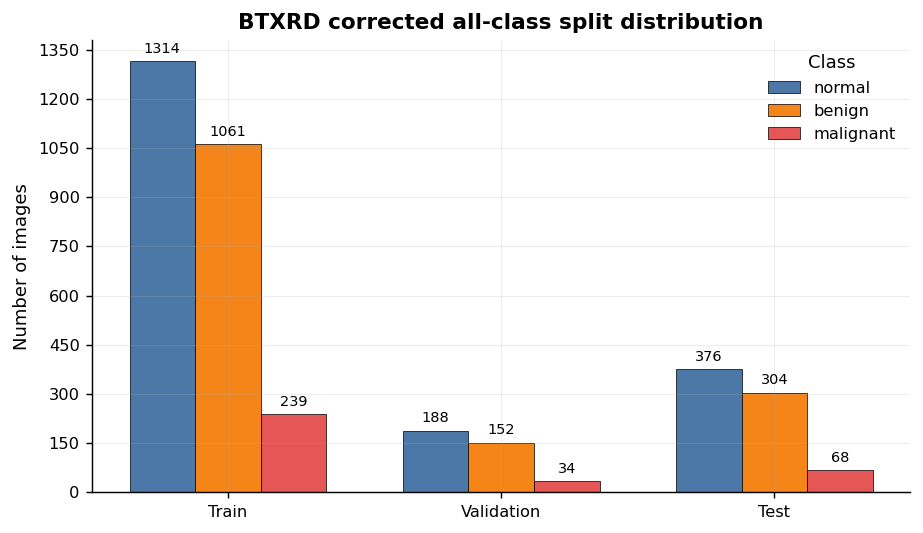

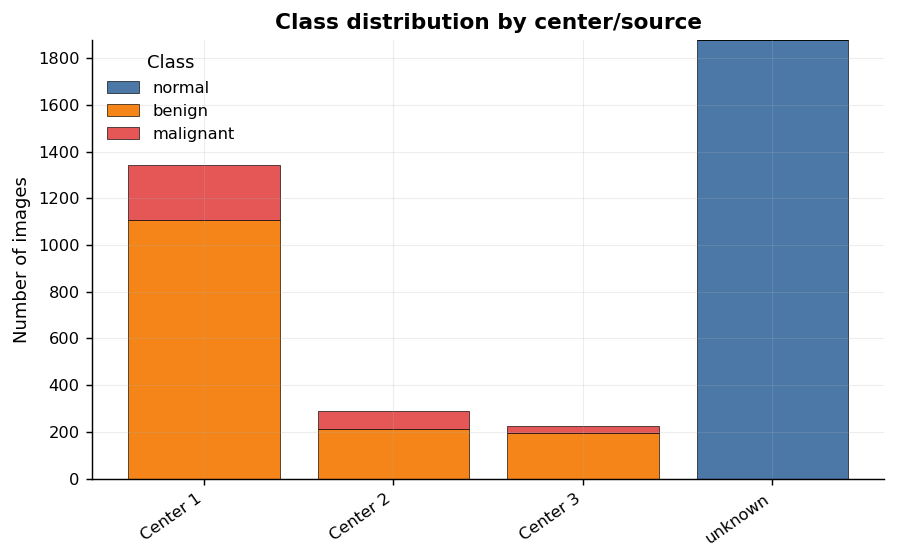

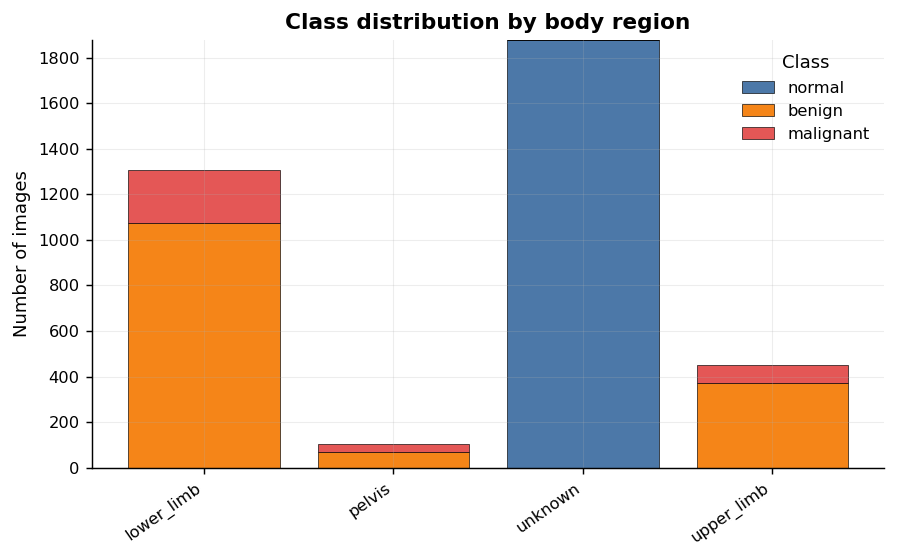

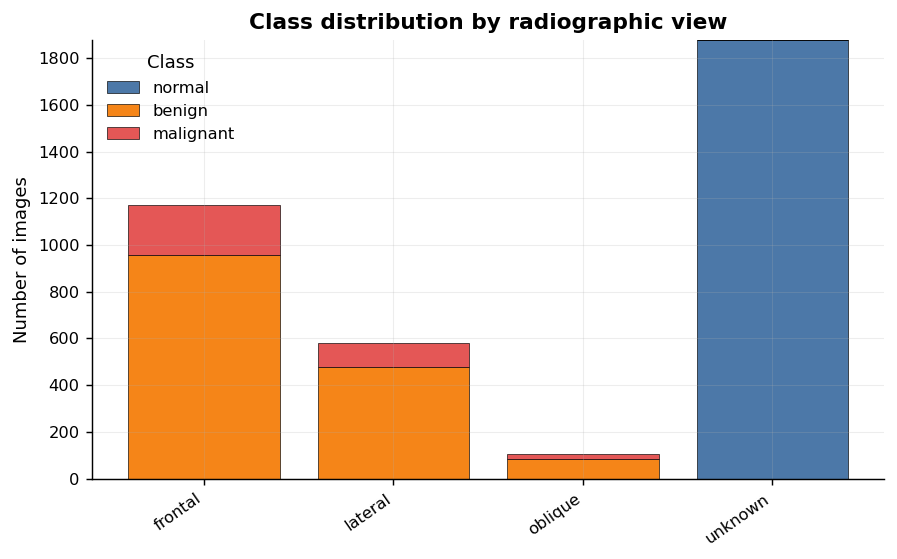

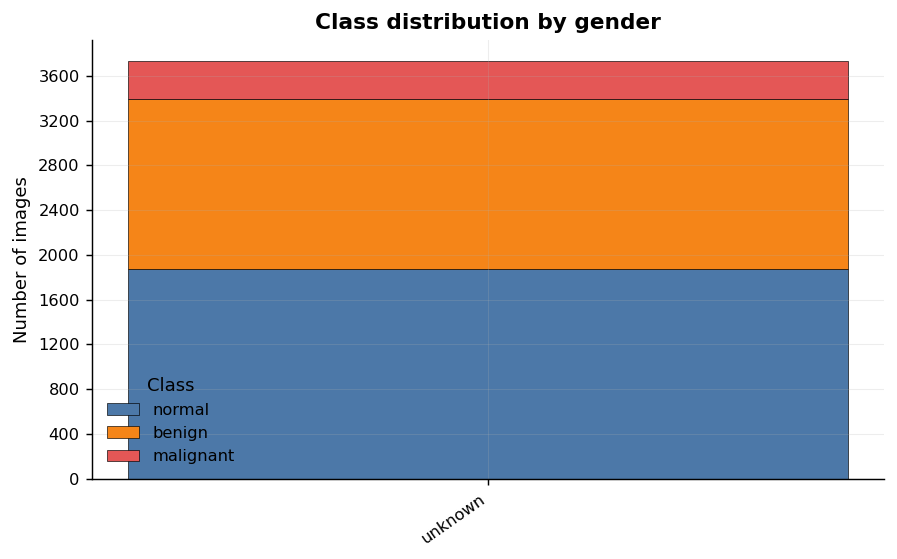

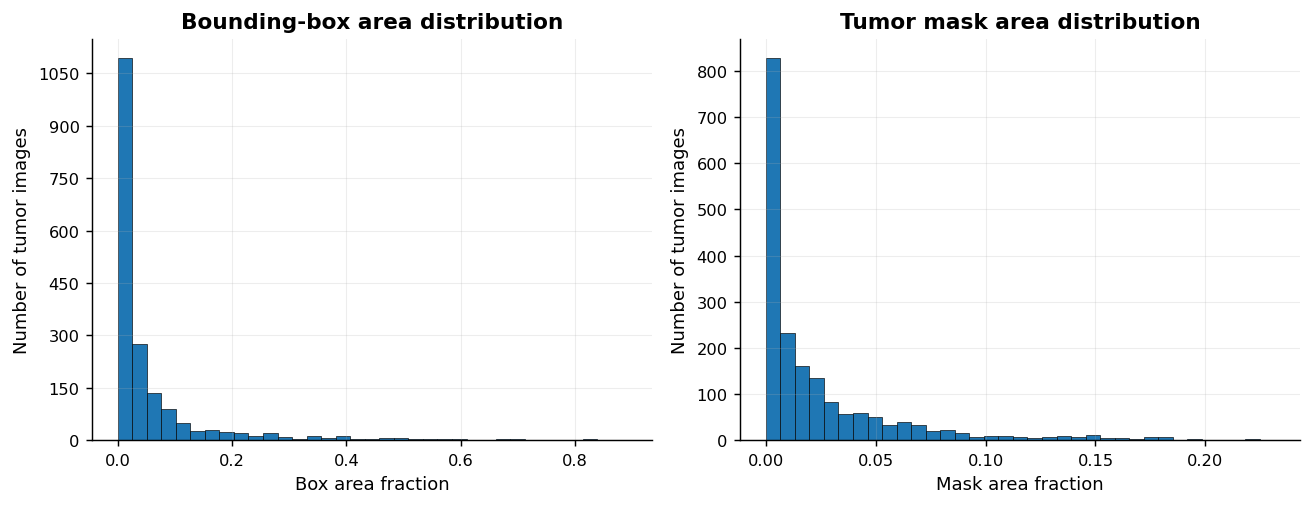

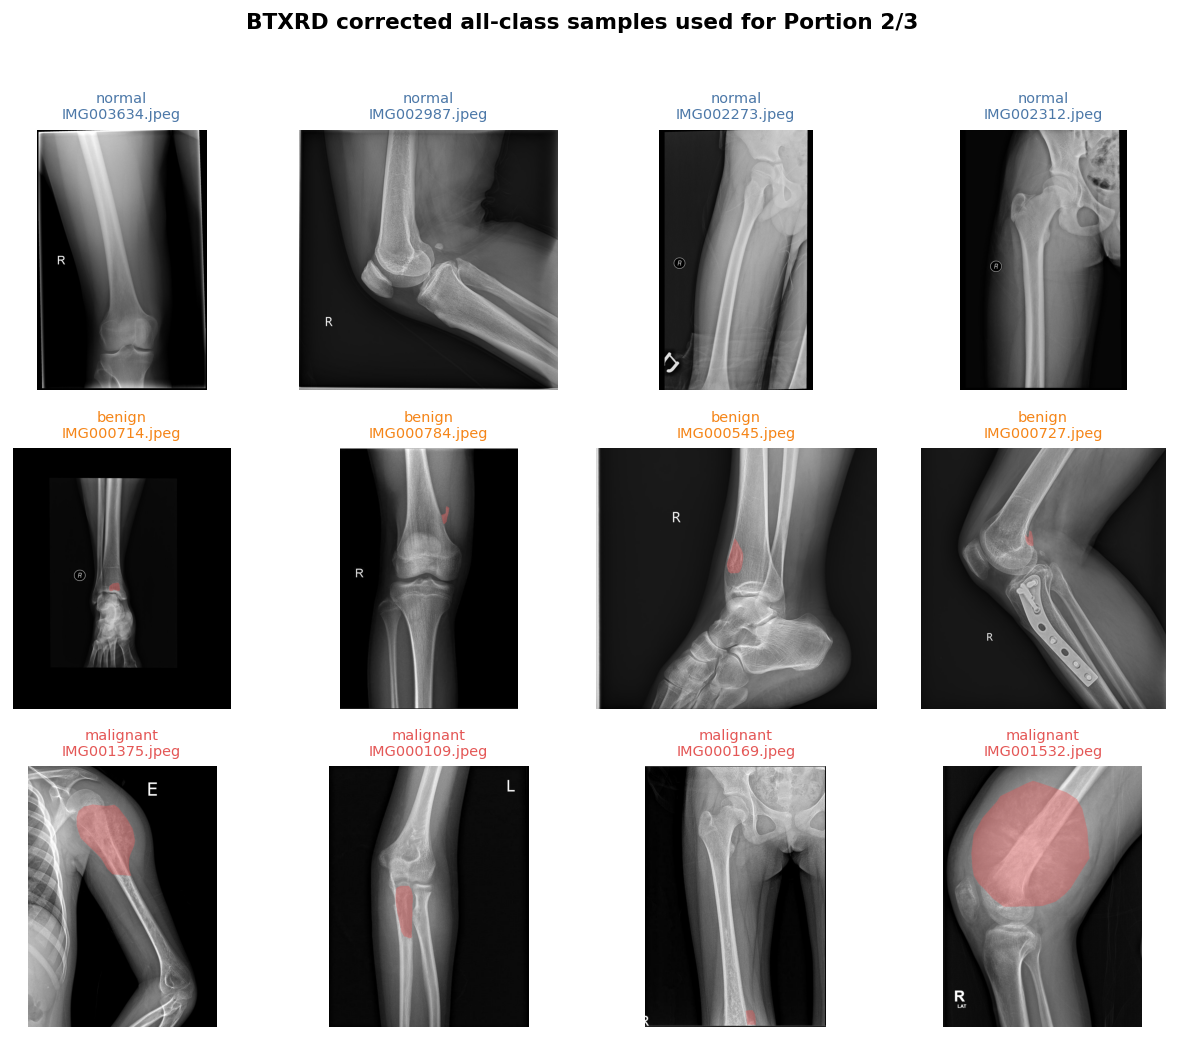

In [4]:
# ============================================================
# 3. Journal-style visuals
# ============================================================
def savefig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


def plot_split_class_distribution(train_df, val_df, test_df):
    rows = []
    for split, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
        vc = df["label_3class"].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
        for lab, n in vc.items():
            rows.append({"split": split, "class": lab, "count": n})
    plot_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    x = np.arange(3)
    width = 0.24
    for i, lab in enumerate(LABEL_ORDER):
        vals = plot_df[plot_df["class"] == lab]["count"].values
        bars = ax.bar(x + (i-1)*width, vals, width=width, label=lab, color=CLASS_COLORS[lab], edgecolor="black", linewidth=0.4)
        ax.bar_label(bars, padding=3, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(["Train", "Validation", "Test"])
    ax.set_ylabel("Number of images")
    ax.set_title("BTXRD corrected all-class split distribution", weight="bold")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(frameon=False, title="Class")
    savefig(FIG_DIR / "fig_p2_corrected_split_class_distribution.png")


def plot_stacked_by_column(df_all, col, fname, title):
    if col not in df_all.columns:
        print(f"Skipped {col}: column not found")
        return None
    temp = df_all.copy()
    temp[col] = temp[col].fillna("unknown").astype(str)
    table = pd.crosstab(temp[col], temp["label_3class"])
    table = table.reindex(columns=LABEL_ORDER).fillna(0).astype(int)
    # Keep manageable top categories.
    if len(table) > 14:
        keep = table.sum(axis=1).sort_values(ascending=False).head(12).index
        other = table.drop(index=keep).sum(axis=0).to_frame().T
        other.index = ["other"]
        table = pd.concat([table.loc[keep], other], axis=0)
    fig, ax = plt.subplots(figsize=(max(7.0, 0.55*len(table)), 4.4))
    x = np.arange(len(table))
    bottom = np.zeros(len(table))
    for lab in LABEL_ORDER:
        vals = table[lab].values
        ax.bar(x, vals, bottom=bottom, label=lab, color=CLASS_COLORS[lab], edgecolor="black", linewidth=0.35)
        bottom += vals
    ax.set_xticks(x)
    ax.set_xticklabels(table.index.astype(str), rotation=35, ha="right")
    ax.set_ylabel("Number of images")
    ax.set_title(title, weight="bold")
    ax.legend(frameon=False, title="Class")
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    savefig(FIG_DIR / fname)
    return table


def plot_bbox_mask_area(df_all):
    fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0))
    for ax, col, title, xlabel in [
        (axes[0], "bbox_area_frac", "Bounding-box area distribution", "Box area fraction"),
        (axes[1], "mask_area_frac", "Tumor mask area distribution", "Mask area fraction"),
    ]:
        if col not in df_all.columns:
            ax.axis("off"); continue
        vals = pd.to_numeric(df_all.loc[df_all["label_id"] > 0, col], errors="coerce").dropna()
        vals = vals[(vals > 0) & np.isfinite(vals)]
        ax.hist(vals, bins=35, edgecolor="black", linewidth=0.35)
        ax.set_title(title, weight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Number of tumor images")
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    savefig(FIG_DIR / "fig_p2_bbox_mask_area_distributions.png")


def load_pil_rgb(path):
    img = Image.open(path).convert("L")
    img = ImageOps.autocontrast(img)
    return Image.merge("RGB", [img, img, img])


def overlay_mask_on_image(img, mask, alpha=0.42):
    img = img.convert("RGBA")
    mask = mask.convert("L").resize(img.size, Image.Resampling.NEAREST)
    red = Image.new("RGBA", img.size, (228, 87, 86, int(255*alpha)))
    out = Image.composite(red, img, mask)
    return Image.alpha_composite(img, out).convert("RGB")


def sample_grid(df_all, fname="fig_p2_corrected_allclass_samples_with_masks.png", n_per_class=4):
    samples = []
    for lab in LABEL_ORDER:
        sub = df_all[df_all["label_3class"] == lab]
        if len(sub) == 0: continue
        samples.append(sub.sample(min(n_per_class, len(sub)), random_state=SEED))
    s_df = pd.concat(samples).reset_index(drop=True)
    rows = len(LABEL_ORDER)
    cols = n_per_class
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.4, rows*2.6))
    if rows == 1: axes = np.array([axes])
    for r, lab in enumerate(LABEL_ORDER):
        sub = s_df[s_df["label_3class"] == lab].reset_index(drop=True)
        for c in range(cols):
            ax = axes[r, c]
            ax.axis("off")
            if c >= len(sub):
                continue
            row = sub.iloc[c]
            try:
                img = load_pil_rgb(row["resolved_image_path"])
                if lab != "normal" and pd.notna(row.get("resolved_mask_path", np.nan)) and Path(str(row["resolved_mask_path"])).exists():
                    mask = Image.open(row["resolved_mask_path"]).convert("L")
                    img = overlay_mask_on_image(img, mask)
                ax.imshow(img, cmap="gray")
                ax.set_title(f"{lab}\n{Path(str(row['resolved_image_path'])).name}", fontsize=8, color=CLASS_COLORS[lab])
            except Exception as e:
                ax.text(0.5, 0.5, str(e), ha="center", va="center", fontsize=7)
    fig.suptitle("BTXRD corrected all-class samples used for Portion 2/3", weight="bold", y=1.02)
    savefig(FIG_DIR / fname)

all_df = pd.concat([train_df.assign(split="train"), val_df.assign(split="val"), test_df.assign(split="test")], ignore_index=True)
plot_split_class_distribution(train_df, val_df, test_df)
for col, fname, title in [
    ("center", "fig_p2_class_by_center.png", "Class distribution by center/source"),
    ("body_region", "fig_p2_class_by_body_region.png", "Class distribution by body region"),
    ("view_angle", "fig_p2_class_by_view_angle.png", "Class distribution by radiographic view"),
    ("gender", "fig_p2_class_by_gender.png", "Class distribution by gender"),
]:
    plot_stacked_by_column(all_df, col, fname, title)
plot_bbox_mask_area(all_df)
sample_grid(all_df)

## 4. Metadata vectorizer and PyTorch dataset

Only clinical metadata that can reasonably be available before model inference is used:

- age,
- gender/sex,
- body region/anatomical site,
- view angle.

`center` is **not** used as diagnostic input. It is used only for the adversarial center-invariance branch.

In [5]:
# ============================================================
# 4. Metadata vectorizer and image dataset
# ============================================================
class MetadataVectorizer:
    """Metadata encoder with leakage guard.

    Normal images in this Kaggle version may be recovered from the raw image folder,
    while tumor images come from dataset.xlsx. Therefore some clinical metadata fields
    can be systematically missing for normal cases. For a journal-safe result, columns
    with strongly class-dependent missingness are automatically removed.
    """
    def __init__(self, max_missing_gap=0.55, min_class_coverage=0.20):
        self.numeric_cols = []
        self.categorical_cols = []
        self.num_median = {}
        self.num_mean = {}
        self.num_std = {}
        self.categories = {}
        self.dim = 0
        self.max_missing_gap = max_missing_gap
        self.min_class_coverage = min_class_coverage
        self.dropped_columns = []
        self.coverage_table = pd.DataFrame()

    @staticmethod
    def _non_missing_mask(s):
        ss = s.copy()
        mask = ss.notna()
        txt = ss.astype(str).str.strip().str.lower()
        mask &= ~txt.isin(["", "nan", "none", "null", "unknown", "not_available", "na"])
        return mask

    def _metadata_coverage_by_class(self, df, columns):
        rows = []
        for c in columns:
            non_missing = self._non_missing_mask(df[c]) if c in df.columns else pd.Series(False, index=df.index)
            for lab in LABEL_ORDER:
                idx = df["label_3class"].eq(lab)
                cov = float(non_missing[idx].mean()) if idx.any() else 0.0
                rows.append({"column": c, "class": lab, "coverage": cov})
        return pd.DataFrame(rows)

    def _keep_column(self, df, c):
        non_missing = self._non_missing_mask(df[c])
        if float(non_missing.mean()) < 0.05:
            self.dropped_columns.append({"column": c, "reason": "overall coverage < 5%"})
            return False
        class_cov = []
        for lab in LABEL_ORDER:
            idx = df["label_3class"].eq(lab)
            if idx.any():
                class_cov.append(float(non_missing[idx].mean()))
        if class_cov:
            gap = max(class_cov) - min(class_cov)
            if min(class_cov) < self.min_class_coverage and gap > self.max_missing_gap:
                self.dropped_columns.append({
                    "column": c,
                    "reason": f"class-dependent missingness: min_cov={min(class_cov):.2f}, max_cov={max(class_cov):.2f}",
                })
                return False
        return True

    def fit(self, df):
        candidates_numeric = ["age"]
        candidates_cat = [
            "gender", "sex", "body_region", "anatomical_site", "site", "view_angle", "shooting_angle"
        ]
        candidate_cols = [c for c in candidates_numeric + candidates_cat if c in df.columns]
        self.coverage_table = self._metadata_coverage_by_class(df, candidate_cols)
        if len(self.coverage_table):
            self.coverage_table.to_csv(TABLE_DIR / "metadata_coverage_by_class.csv", index=False)

        safe_numeric = []
        safe_cat = []
        if cfg.use_metadata:
            for c in candidates_numeric:
                if c in df.columns and self._keep_column(df, c):
                    safe_numeric.append(c)
            for c in candidates_cat:
                if c in df.columns and c not in safe_cat and self._keep_column(df, c):
                    safe_cat.append(c)

        self.numeric_cols = safe_numeric
        self.categorical_cols = list(dict.fromkeys(safe_cat))

        for c in self.numeric_cols:
            vals = pd.to_numeric(df[c], errors="coerce")
            med = float(vals.median()) if vals.notna().any() else 0.0
            vals_f = vals.fillna(med)
            mean = float(vals_f.mean())
            std = float(vals_f.std()) if float(vals_f.std()) > 1e-6 else 1.0
            self.num_median[c] = med
            self.num_mean[c] = mean
            self.num_std[c] = std
        for c in self.categorical_cols:
            vals = df[c].fillna("unknown").astype(str).str.lower().str.strip()
            vals = vals.replace({"": "unknown", "nan": "unknown", "none": "unknown", "null": "unknown"})
            cats = sorted(vals.unique().tolist())
            if "unknown" not in cats:
                cats = ["unknown"] + cats
            self.categories[c] = cats
        self.dim = len(self.numeric_cols) + sum(len(v) for v in self.categories.values())
        if self.dim == 0:
            # One constant zero feature keeps downstream model code simple while disabling metadata information.
            self.dim = 1
        if self.dropped_columns:
            pd.DataFrame(self.dropped_columns).to_csv(TABLE_DIR / "metadata_columns_dropped_leakage_guard.csv", index=False)
        return self

    def transform_row(self, row):
        out = []
        for c in self.numeric_cols:
            v = pd.to_numeric(pd.Series([row.get(c, np.nan)]), errors="coerce").iloc[0]
            if pd.isna(v):
                v = self.num_median[c]
            out.append((float(v) - self.num_mean[c]) / self.num_std[c])
        for c in self.categorical_cols:
            cats = self.categories[c]
            v = str(row.get(c, "unknown") if pd.notna(row.get(c, np.nan)) else "unknown").lower().strip()
            if v in {"", "nan", "none", "null"}:
                v = "unknown"
            if v not in cats:
                v = "unknown"
            out.extend([1.0 if v == cat else 0.0 for cat in cats])
        if not out:
            out = [0.0]
        return np.asarray(out, dtype=np.float32)

    def transform_df(self, df):
        return np.stack([self.transform_row(row) for _, row in df.iterrows()]).astype(np.float32)

meta_vec = MetadataVectorizer().fit(train_df)
print("Metadata numeric columns kept:", meta_vec.numeric_cols)
print("Metadata categorical columns kept:", meta_vec.categorical_cols)
print("Metadata dimension:", meta_vec.dim)
if meta_vec.dropped_columns:
    print("Metadata columns dropped by leakage guard:")
    display(pd.DataFrame(meta_vec.dropped_columns))
if len(meta_vec.coverage_table):
    print("Metadata coverage by class:")
    display(meta_vec.coverage_table.pivot(index="column", columns="class", values="coverage").reindex(columns=LABEL_ORDER))


# Center encoder for adversarial branch.
if "center" in train_df.columns:
    center_values = train_df["center"].fillna("unknown").astype(str).str.lower().str.strip()
    center_categories = sorted(center_values.unique().tolist())
else:
    center_categories = ["unknown"]
CENTER_TO_ID = {c: i for i, c in enumerate(center_categories)}
print("Center categories:", CENTER_TO_ID)


def get_center_id(row):
    c = str(row.get("center", "unknown") if pd.notna(row.get("center", np.nan)) else "unknown").lower().strip()
    return CENTER_TO_ID.get(c, CENTER_TO_ID.get("unknown", 0))


def read_mask(mask_path, size):
    if pd.isna(mask_path) or not Path(str(mask_path)).exists():
        return Image.new("L", size, 0)
    try:
        m = Image.open(mask_path).convert("L")
        return m
    except Exception:
        return Image.new("L", size, 0)


def resize_pad_image_mask_bbox(img, mask, bbox_xyxy, out_size):
    # Preserve aspect ratio and transform mask/bbox to normalized padded coordinates.
    w, h = img.size
    scale = out_size / max(w, h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    left = (out_size - new_w) // 2
    top = (out_size - new_h) // 2

    img_r = img.resize((new_w, new_h), Image.Resampling.BILINEAR)
    mask_r = mask.resize((new_w, new_h), Image.Resampling.NEAREST)
    img_canvas = Image.new("RGB", (out_size, out_size), (0, 0, 0))
    mask_canvas = Image.new("L", (out_size, out_size), 0)
    img_canvas.paste(img_r, (left, top))
    mask_canvas.paste(mask_r, (left, top))

    # Prefer bbox from mask after transform if present.
    mask_arr = np.asarray(mask_canvas)
    ys, xs = np.where(mask_arr > 0)
    if len(xs) > 0 and len(ys) > 0:
        x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
    elif bbox_xyxy is not None and np.all(np.isfinite(bbox_xyxy)):
        x1, y1, x2, y2 = bbox_xyxy
        x1 = x1 * scale + left
        x2 = x2 * scale + left
        y1 = y1 * scale + top
        y2 = y2 * scale + top
    else:
        x1 = y1 = x2 = y2 = 0
    bbox_norm = np.asarray([x1/out_size, y1/out_size, x2/out_size, y2/out_size], dtype=np.float32)
    bbox_norm = np.clip(bbox_norm, 0.0, 1.0)
    return img_canvas, mask_canvas, bbox_norm


def random_train_augment(img, mask, bbox_norm, allow_flip=True):
    # Contrast/brightness are safe for X-ray if mild.
    if random.random() < 0.60:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.85, 1.25))
    if random.random() < 0.45:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.90, 1.12))
    # Horizontal flip; update mask and bbox from mask afterwards.
    if allow_flip and random.random() < 0.50:
        img = ImageOps.mirror(img)
        mask = ImageOps.mirror(mask)
    # Small rotation; bbox will be recalculated from mask if tumor.
    if random.random() < 0.35:
        angle = random.uniform(-7.0, 7.0)
        img = img.rotate(angle, resample=Image.Resampling.BILINEAR, fillcolor=(0, 0, 0))
        mask = mask.rotate(angle, resample=Image.Resampling.NEAREST, fillcolor=0)
    # Recompute bbox from transformed mask if possible.
    arr = np.asarray(mask)
    ys, xs = np.where(arr > 0)
    if len(xs) > 0 and len(ys) > 0:
        s = img.size[0]
        bbox_norm = np.asarray([xs.min()/s, ys.min()/s, xs.max()/s, ys.max()/s], dtype=np.float32)
    return img, mask, bbox_norm


def pil_to_tensor_normalized(img):
    arr = np.asarray(img).astype(np.float32) / 255.0
    # Grayscale RGB, but ImageNet normalization works well for pretrained encoders.
    mean = np.asarray([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.asarray([0.229, 0.224, 0.225], dtype=np.float32)
    arr = (arr - mean) / std
    return torch.from_numpy(arr).permute(2, 0, 1).float()


class BTXRDDataset(Dataset):
    def __init__(self, df, meta_vectorizer, img_size=448, train=False):
        self.df = df.reset_index(drop=True).copy()
        self.meta_vectorizer = meta_vectorizer
        self.img_size = img_size
        self.train = train
        self.meta_mat = meta_vectorizer.transform_df(self.df)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = str(row["resolved_image_path"])
        try:
            img_l = Image.open(img_path).convert("L")
            img_l = ImageOps.autocontrast(img_l)
        except Exception:
            img_l = Image.new("L", (self.img_size, self.img_size), 0)
        img = Image.merge("RGB", [img_l, img_l, img_l])

        mask_orig = read_mask(row.get("resolved_mask_path", np.nan), img_l.size)
        bbox_cols = ["bbox_x1", "bbox_y1", "bbox_x2", "bbox_y2"]
        if all(c in row.index for c in bbox_cols):
            bbox_xyxy = pd.to_numeric(row[bbox_cols], errors="coerce").values.astype(np.float32)
        else:
            bbox_xyxy = None
        img, mask, bbox = resize_pad_image_mask_bbox(img, mask_orig, bbox_xyxy, self.img_size)
        if self.train:
            img, mask, bbox = random_train_augment(img, mask, bbox, allow_flip=cfg.allow_horizontal_flip)
        img_tensor = pil_to_tensor_normalized(img)
        mask_arr = (np.asarray(mask).astype(np.float32) > 0).astype(np.float32)
        mask_tensor = torch.from_numpy(mask_arr).unsqueeze(0)
        label_id = int(row["label_id"])
        has_tumor = int(label_id > 0)
        if not has_tumor:
            mask_tensor.zero_()
            bbox = np.zeros(4, dtype=np.float32)
        sample = {
            "image": img_tensor,
            "mask": mask_tensor,
            "bbox": torch.tensor(bbox, dtype=torch.float32),
            "label": torch.tensor(label_id, dtype=torch.long),
            "tumor": torch.tensor(has_tumor, dtype=torch.long),
            "malignant": torch.tensor(int(label_id == 2), dtype=torch.long),
            "metadata": torch.tensor(self.meta_mat[idx], dtype=torch.float32),
            "center": torch.tensor(get_center_id(row), dtype=torch.long),
            "image_path": img_path,
            "image_id": str(row.get("image_id", Path(img_path).stem)),
        }
        return sample

train_ds = BTXRDDataset(train_df, meta_vec, cfg.img_size, train=True)
val_ds = BTXRDDataset(val_df, meta_vec, cfg.img_size, train=False)
test_ds = BTXRDDataset(test_df, meta_vec, cfg.img_size, train=False)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))
sample = train_ds[0]
print("Sample image:", sample["image"].shape, "mask:", sample["mask"].shape, "metadata:", sample["metadata"].shape)

Metadata numeric columns kept: []
Metadata categorical columns kept: []
Metadata dimension: 1
Metadata columns dropped by leakage guard:


,column,reason
0,age,"class-dependent missingness: min_cov=0.00, max..."
1,gender,overall coverage < 5%
2,body_region,"class-dependent missingness: min_cov=0.00, max..."
3,anatomical_site,"class-dependent missingness: min_cov=0.00, max..."
4,view_angle,"class-dependent missingness: min_cov=0.00, max..."


Metadata coverage by class:


class,normal,benign,malignant
column,,,
age,0.0,1.0,1.000000
anatomical_site,0.0,1.0,0.995816
body_region,0.0,1.0,1.000000
gender,0.0,0.0,0.000000
view_angle,0.0,1.0,1.000000


Center categories: {'center 1': 0, 'center 2': 1, 'center 3': 2, 'unknown': 3}
Dataset sizes: 2614 374 748
Sample image: torch.Size([3, 448, 448]) mask: torch.Size([1, 448, 448]) metadata: torch.Size([1])


In [6]:
# ============================================================
# 4b. Dataloaders and class weights
# ============================================================
def make_class_weights(df):
    counts = df["label_id"].value_counts().reindex([0,1,2]).fillna(0).values.astype(np.float32)
    counts = np.maximum(counts, 1.0)
    weights = counts.sum() / (len(counts) * counts)
    # Emphasize malignant class mildly.
    weights[2] *= 1.25
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)

class_weights = make_class_weights(train_df).to(DEVICE)
print("Class weights:", class_weights.detach().cpu().numpy())


def make_loader(ds, df, train=False):
    if train and cfg.use_weighted_sampler:
        labels = df["label_id"].values
        counts = np.bincount(labels, minlength=3).astype(np.float32)
        sample_weights = 1.0 / np.maximum(counts[labels], 1.0)
        # Extra malignant sampling focus.
        sample_weights = sample_weights * np.where(labels == 2, 1.35, 1.0)
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        return DataLoader(ds, batch_size=cfg.batch_size, sampler=sampler, num_workers=cfg.num_workers, pin_memory=True)
    return DataLoader(ds, batch_size=cfg.batch_size, shuffle=train, num_workers=cfg.num_workers, pin_memory=True)

train_loader = make_loader(train_ds, train_df, train=True)
val_loader = make_loader(val_ds, val_df, train=False)
test_loader = make_loader(test_ds, test_df, train=False)

Class weights: [0.3292781 0.4077959 2.262926 ]


# Portion 2 — Strong baseline system

Baseline models are needed because the proposed method must prove that its extra complexity matters. This notebook trains:

1. **metadata-only baseline**,
2. **image-only deep baseline**,
3. optional multiple image backbones.

Detection and segmentation baseline hooks are included through BTX-TrustNet's mask/box metrics; the final Portion 4 notebook can add YOLO/nnU-Net external baselines if desired.

In [8]:
# ============================================================
# 5. Metrics utilities
# ============================================================
def softmax_np(logits):
    logits = np.asarray(logits)
    logits = logits - logits.max(axis=1, keepdims=True)
    e = np.exp(logits)
    return e / np.clip(e.sum(axis=1, keepdims=True), 1e-12, None)


def expected_calibration_error(probs, labels, n_bins=15):
    probs = np.asarray(probs)
    labels = np.asarray(labels)
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == labels).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    bin_rows = []
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if mask.sum() == 0:
            bin_rows.append({"bin_left": lo, "bin_right": hi, "n": 0, "accuracy": np.nan, "confidence": np.nan})
            continue
        acc = correct[mask].mean()
        c = conf[mask].mean()
        ece += mask.mean() * abs(acc - c)
        bin_rows.append({"bin_left": lo, "bin_right": hi, "n": int(mask.sum()), "accuracy": acc, "confidence": c})
    return float(ece), pd.DataFrame(bin_rows)


def classification_metrics_from_probs(probs, labels, prefix=""):
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    preds = probs.argmax(axis=1)
    out = {}
    out[prefix+"accuracy"] = accuracy_score(labels, preds)
    out[prefix+"balanced_accuracy"] = balanced_accuracy_score(labels, preds)
    out[prefix+"macro_f1"] = f1_score(labels, preds, average="macro", zero_division=0)
    out[prefix+"weighted_f1"] = f1_score(labels, preds, average="weighted", zero_division=0)
    out[prefix+"kappa"] = cohen_kappa_score(labels, preds)
    precision, recall, f1, support = precision_recall_fscore_support(labels, preds, labels=[0,1,2], zero_division=0)
    for i, lab in enumerate(LABEL_ORDER):
        out[prefix+f"{lab}_precision"] = precision[i]
        out[prefix+f"{lab}_sensitivity"] = recall[i]
        out[prefix+f"{lab}_f1"] = f1[i]
        out[prefix+f"{lab}_support"] = int(support[i])
        # specificity for one-vs-rest
        y_true_bin = (labels == i).astype(int)
        y_pred_bin = (preds == i).astype(int)
        tn = np.sum((y_true_bin == 0) & (y_pred_bin == 0))
        fp = np.sum((y_true_bin == 0) & (y_pred_bin == 1))
        out[prefix+f"{lab}_specificity"] = float(tn / max(tn + fp, 1))
    try:
        out[prefix+"macro_auroc_ovr"] = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except Exception:
        out[prefix+"macro_auroc_ovr"] = np.nan
    try:
        y_bin = label_binarize(labels, classes=[0,1,2])
        out[prefix+"macro_auprc"] = average_precision_score(y_bin, probs, average="macro")
        out[prefix+"malignant_auprc"] = average_precision_score((labels == 2).astype(int), probs[:,2])
    except Exception:
        out[prefix+"macro_auprc"] = np.nan
        out[prefix+"malignant_auprc"] = np.nan
    ece, _ = expected_calibration_error(probs, labels)
    out[prefix+"ece"] = ece
    try:
        # Multiclass Brier = mean sum over classes.
        y_oh = np.eye(3)[labels]
        out[prefix+"brier_multiclass"] = float(np.mean(np.sum((probs - y_oh) ** 2, axis=1)))
    except Exception:
        out[prefix+"brier_multiclass"] = np.nan
    return out


def journal_score(metrics):
    # Higher is better. Lower ECE improves score.
    ece_term = 1.0 - float(metrics.get("ece", 0.5))
    return (
        cfg.malignant_priority * float(metrics.get("malignant_sensitivity", 0.0)) +
        cfg.macro_f1_priority * float(metrics.get("macro_f1", 0.0)) +
        cfg.balanced_acc_priority * float(metrics.get("balanced_accuracy", 0.0)) +
        cfg.calibration_priority * ece_term
    )


def plot_confusion(labels, preds, title, fname):
    cm = confusion_matrix(labels, preds, labels=[0,1,2])
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels(LABEL_ORDER, rotation=30, ha="right")
    ax.set_yticks(range(3)); ax.set_yticklabels(LABEL_ORDER)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, weight="bold")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i,j]), ha="center", va="center", fontsize=11, color="black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    savefig(FIG_DIR / fname)


def plot_roc_pr(labels, probs, title_prefix, fname_prefix):
    labels = np.asarray(labels)
    probs = np.asarray(probs)
    y_bin = label_binarize(labels, classes=[0,1,2])
    # ROC
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    for i, lab in enumerate(LABEL_ORDER):
        try:
            fpr, tpr, _ = roc_curve(y_bin[:,i], probs[:,i])
            auc = roc_auc_score(y_bin[:,i], probs[:,i])
            ax.plot(fpr, tpr, lw=2, label=f"{lab} AUC={auc:.3f}", color=CLASS_COLORS[lab])
        except Exception:
            pass
    ax.plot([0,1], [0,1], ls="--", lw=1, color="#555555")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{title_prefix} ROC curves", weight="bold")
    ax.legend(frameon=False)
    savefig(FIG_DIR / f"{fname_prefix}_roc.png")
    # PR
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    for i, lab in enumerate(LABEL_ORDER):
        try:
            prec, rec, _ = precision_recall_curve(y_bin[:,i], probs[:,i])
            ap = average_precision_score(y_bin[:,i], probs[:,i])
            ax.plot(rec, prec, lw=2, label=f"{lab} AP={ap:.3f}", color=CLASS_COLORS[lab])
        except Exception:
            pass
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{title_prefix} precision-recall curves", weight="bold")
    ax.legend(frameon=False)
    savefig(FIG_DIR / f"{fname_prefix}_pr.png")


def plot_reliability(labels, probs, title, fname):
    ece, bins_df = expected_calibration_error(probs, labels)
    fig, ax = plt.subplots(figsize=(4.8, 4.5))
    valid = bins_df[bins_df["n"] > 0]
    ax.plot([0,1], [0,1], ls="--", color="#555555", label="perfect calibration")
    ax.scatter(valid["confidence"], valid["accuracy"], s=np.maximum(valid["n"].values, 8)*4, alpha=0.75, edgecolor="black", linewidth=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Mean confidence")
    ax.set_ylabel("Empirical accuracy")
    ax.set_title(f"{title}\nECE={ece:.3f}", weight="bold")
    ax.legend(frameon=False)
    savefig(FIG_DIR / fname)
    bins_df.to_csv(TABLE_DIR / fname.replace(".png", "_bins.csv"), index=False)

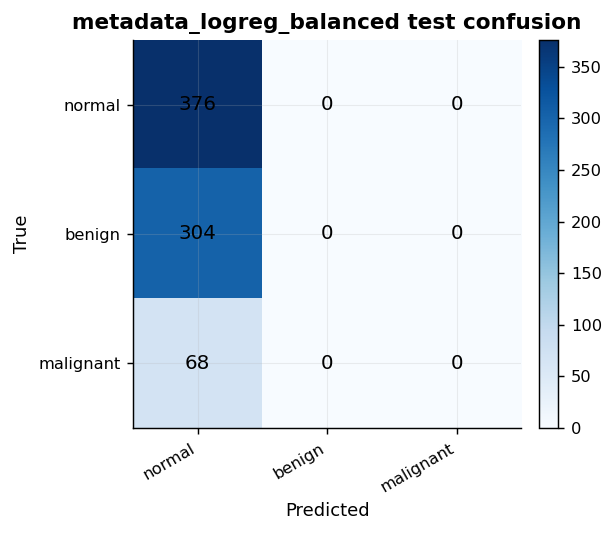

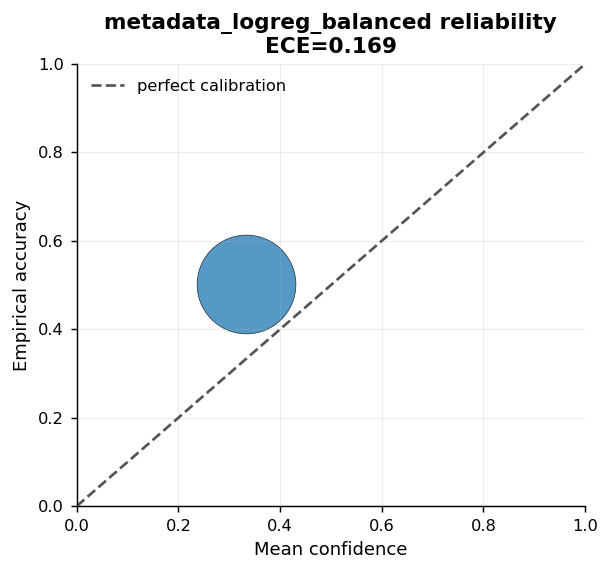

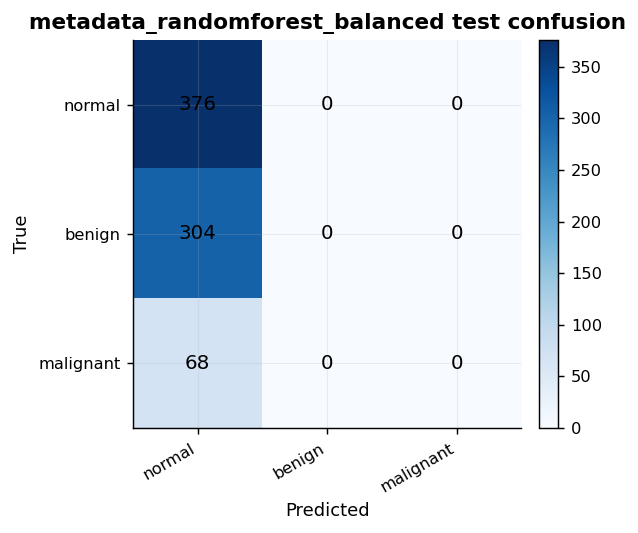

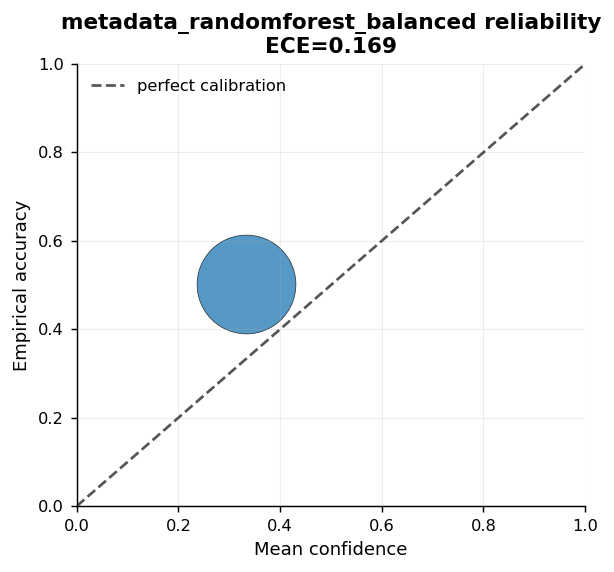

,model,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,val_kappa,val_normal_precision,val_normal_sensitivity,val_normal_f1,val_normal_support,...,test_malignant_precision,test_malignant_sensitivity,test_malignant_f1,test_malignant_support,test_malignant_specificity,test_macro_auroc_ovr,test_macro_auprc,test_malignant_auprc,test_ece,test_brier_multiclass
0,metadata_logreg_balanced,0.502674,0.333333,0.223013,0.336308,0.0,0.502674,1.0,0.669039,188,...,0.0,0.0,0.0,68,1.0,0.5,0.333333,0.090909,0.16934,0.666667
1,metadata_randomforest_balanced,0.502674,0.333333,0.223013,0.336308,0.0,0.502674,1.0,0.669039,188,...,0.0,0.0,0.0,68,1.0,0.5,0.333333,0.090909,0.16934,0.666667


In [9]:
# ============================================================
# 6. Metadata-only baseline
# ============================================================
def run_metadata_baselines():
    X_train = meta_vec.transform_df(train_df)
    X_val = meta_vec.transform_df(val_df)
    X_test = meta_vec.transform_df(test_df)
    y_train = train_df["label_id"].values
    y_val = val_df["label_id"].values
    y_test = test_df["label_id"].values

    models = {
        "metadata_logreg_balanced": LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto"),
        "metadata_randomforest_balanced": RandomForestClassifier(
            n_estimators=350, max_depth=None, random_state=SEED, class_weight="balanced_subsample", n_jobs=-1
        ),
    }
    rows = []
    for name, clf in models.items():
        clf.fit(X_train, y_train)
        probs_val = clf.predict_proba(X_val)
        probs_test = clf.predict_proba(X_test)
        # Ensure 3 columns if a small smoke split misses a class.
        def align_probs(clf, probs):
            out = np.zeros((len(probs), 3), dtype=np.float32)
            for j, cls in enumerate(clf.classes_):
                out[:, int(cls)] = probs[:, j]
            out = out / np.clip(out.sum(axis=1, keepdims=True), 1e-12, None)
            return out
        probs_val = align_probs(clf, probs_val)
        probs_test = align_probs(clf, probs_test)
        val_m = classification_metrics_from_probs(probs_val, y_val, prefix="val_")
        test_m = classification_metrics_from_probs(probs_test, y_test, prefix="test_")
        row = {"model": name, **val_m, **test_m}
        rows.append(row)
        plot_confusion(y_test, probs_test.argmax(1), f"{name} test confusion", f"fig_{name}_confusion.png")
        plot_reliability(y_test, probs_test, f"{name} reliability", f"fig_{name}_reliability.png")
    res = pd.DataFrame(rows)
    res.to_csv(TABLE_DIR / "portion2_metadata_baseline_metrics.csv", index=False)
    display(res)
    return res

metadata_results = run_metadata_baselines()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]


efficientnet_b0 epoch 1/14:   0%|          | 0/654 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

efficientnet_b0 epoch 1: val macro-F1=0.4742, malignant sens=0.9412, ECE=0.1450, score=0.7358


...

efficientnet_b0 epoch 13: val macro-F1=0.7797, malignant sens=0.8235, ECE=0.0854, score=0.8149


efficientnet_b0 epoch 14/14:   0%|          | 0/654 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

efficientnet_b0 epoch 14: val macro-F1=0.7698, malignant sens=0.8235, ECE=0.0709, score=0.8114


eval:   0%|          | 0/187 [00:00<?, ?it/s]

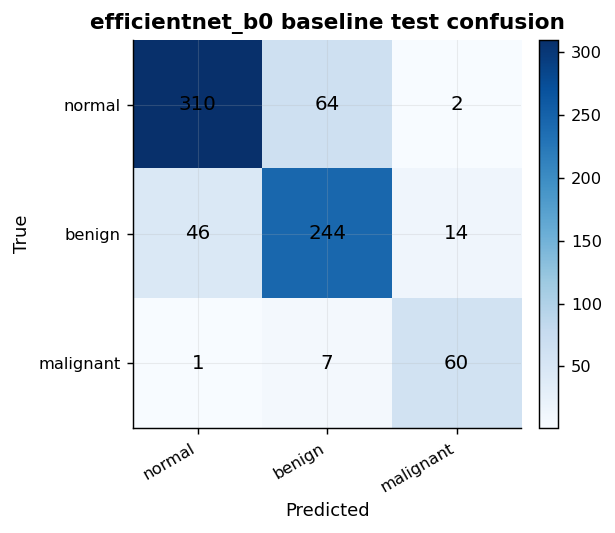

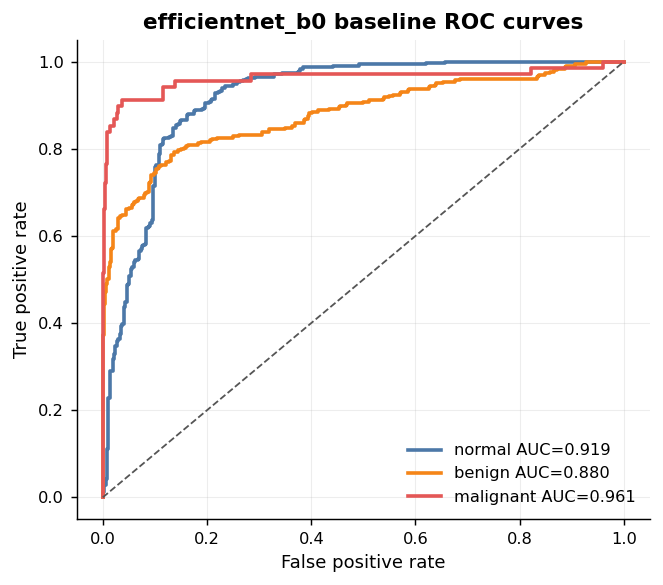

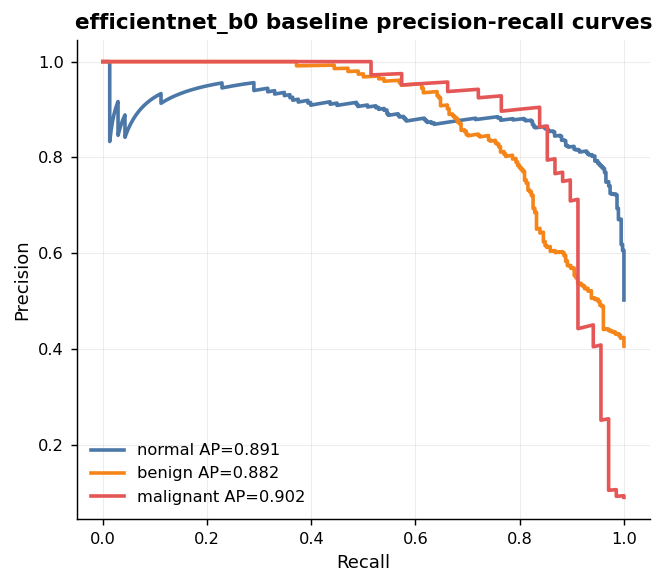

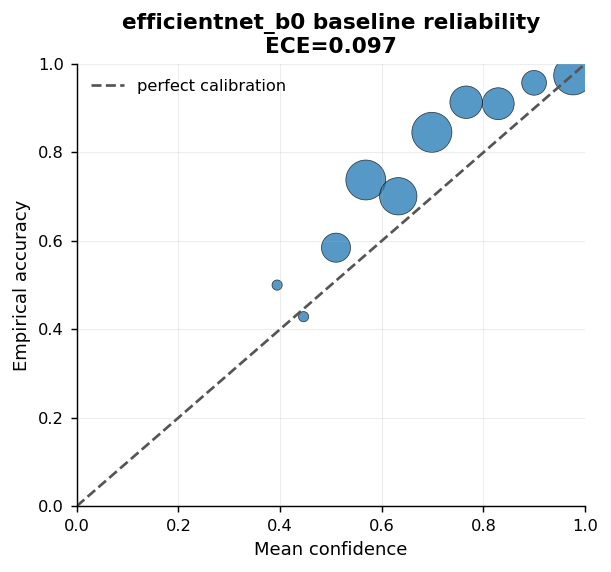

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 167MB/s]


efficientnet_b3 epoch 1/14:   0%|          | 0/654 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

efficientnet_b3 epoch 1: val macro-F1=0.4990, malignant sens=0.9412, ECE=0.1076, score=0.7513


...

efficientnet_b3 epoch 13: val macro-F1=0.7753, malignant sens=0.8235, ECE=0.0507, score=0.8175


efficientnet_b3 epoch 14/14:   0%|          | 0/654 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

efficientnet_b3 epoch 14: val macro-F1=0.7957, malignant sens=0.8529, ECE=0.0729, score=0.8375


eval:   0%|          | 0/187 [00:00<?, ?it/s]

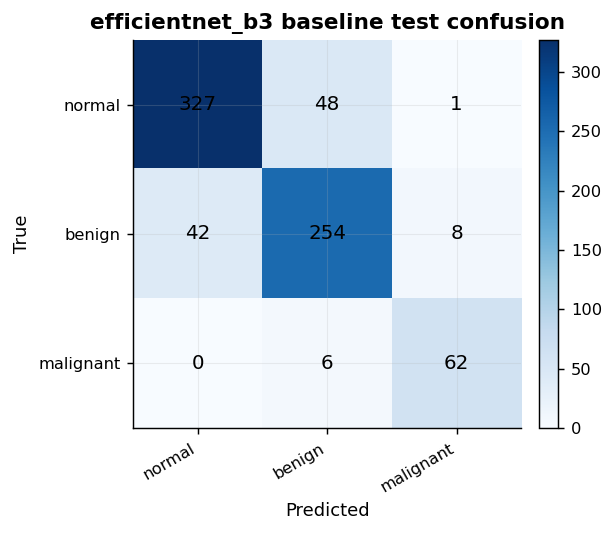

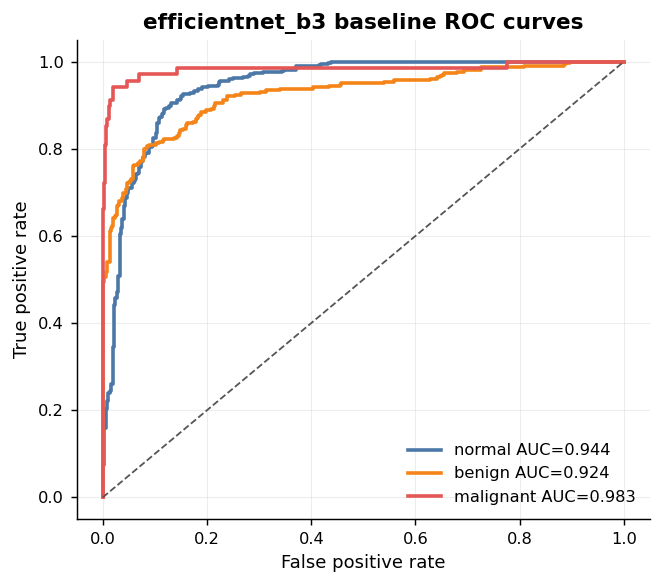

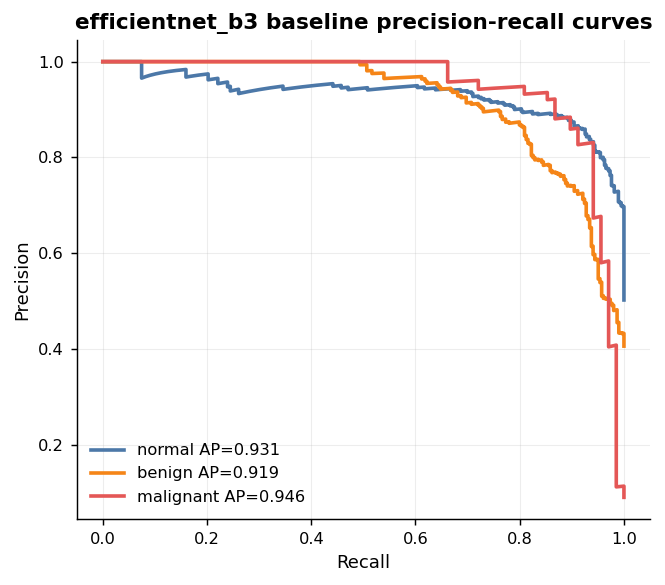

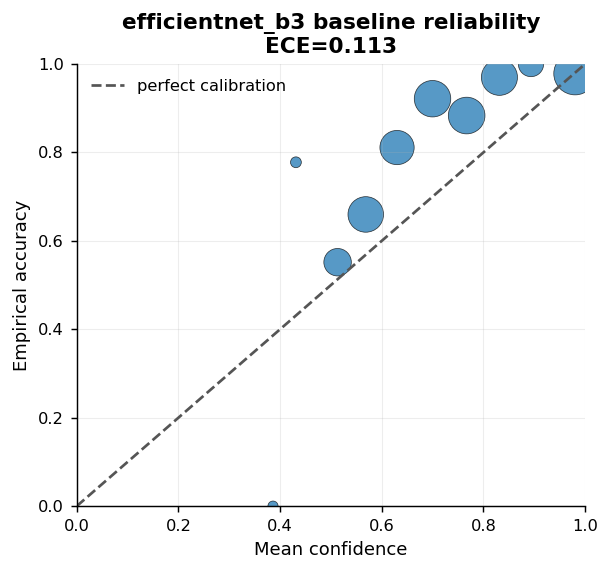

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 213MB/s] 


convnext_tiny epoch 1/14:   0%|          | 0/654 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

convnext_tiny epoch 1: val macro-F1=0.0556, malignant sens=1.0000, ECE=0.6611, score=0.5361


...

convnext_tiny epoch 13: val macro-F1=0.5532, malignant sens=0.8235, ECE=0.0994, score=0.7184


convnext_tiny epoch 14/14:   0%|          | 0/654 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

convnext_tiny epoch 14: val macro-F1=0.5684, malignant sens=0.8235, ECE=0.0993, score=0.7248


eval:   0%|          | 0/187 [00:00<?, ?it/s]

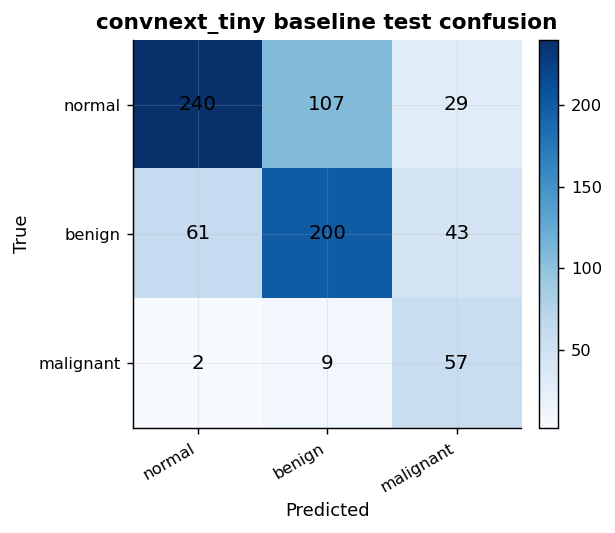

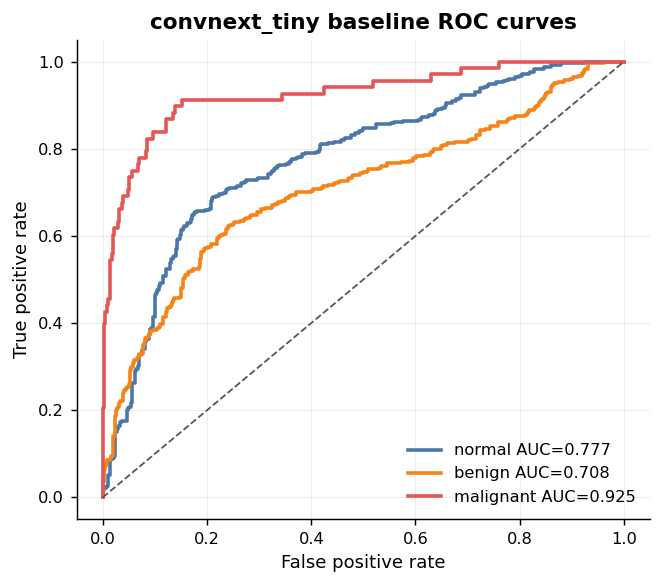

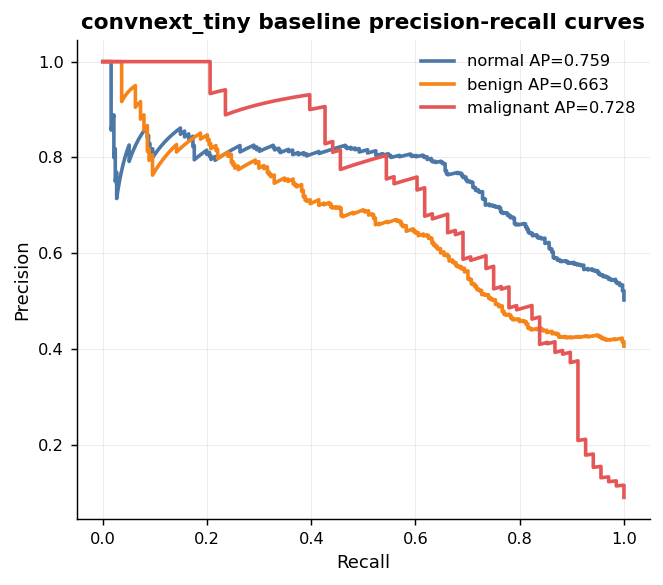

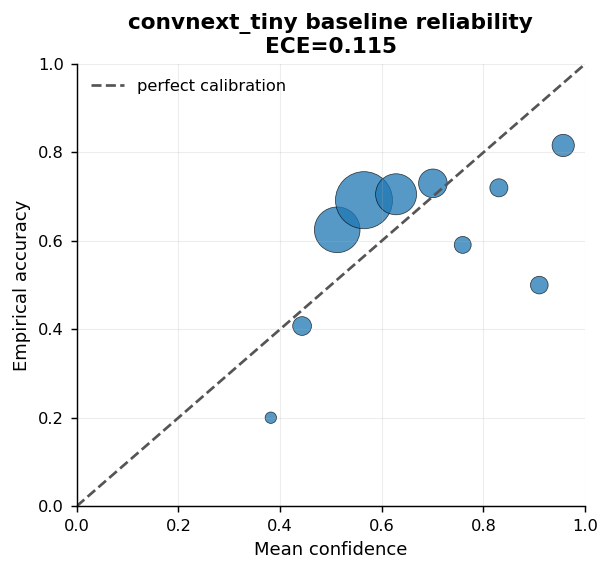

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 171MB/s]  


swin_t epoch 1/14:   0%|          | 0/654 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

swin_t epoch 1: val macro-F1=0.0556, malignant sens=1.0000, ECE=0.6801, score=0.5342


...

swin_t epoch 13: val macro-F1=0.0771, malignant sens=1.0000, ECE=0.5620, score=0.5542


swin_t epoch 14/14:   0%|          | 0/654 [00:00<?, ?it/s]

eval:   0%|          | 0/94 [00:00<?, ?it/s]

swin_t epoch 14: val macro-F1=0.0984, malignant sens=0.9706, ECE=0.5215, score=0.5524


eval:   0%|          | 0/187 [00:00<?, ?it/s]

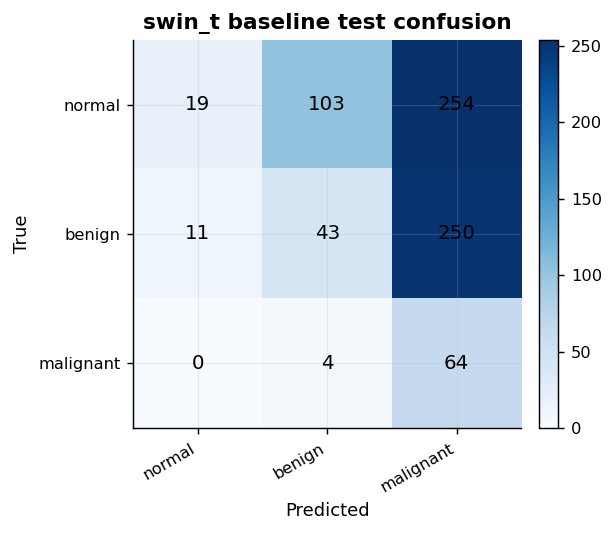

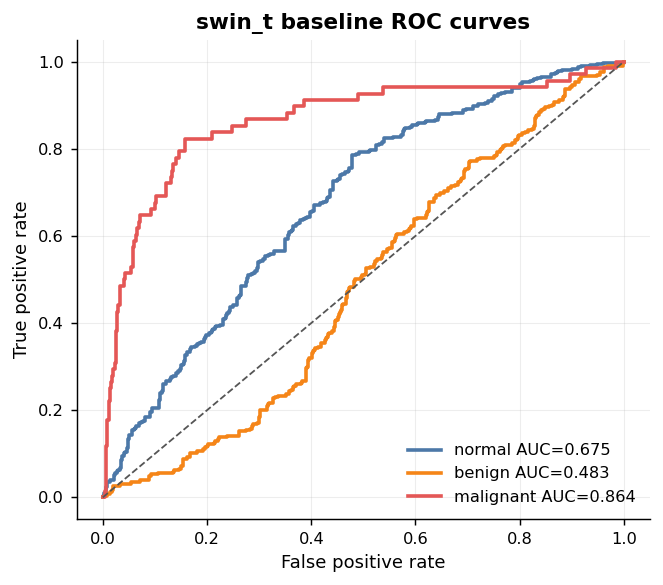

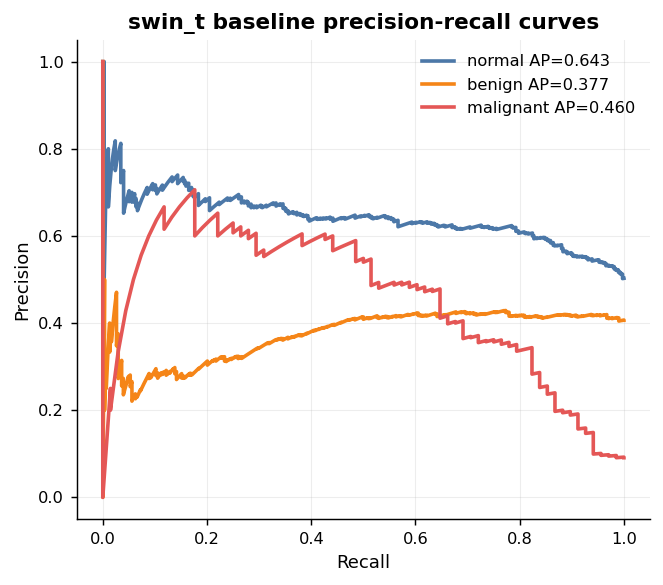

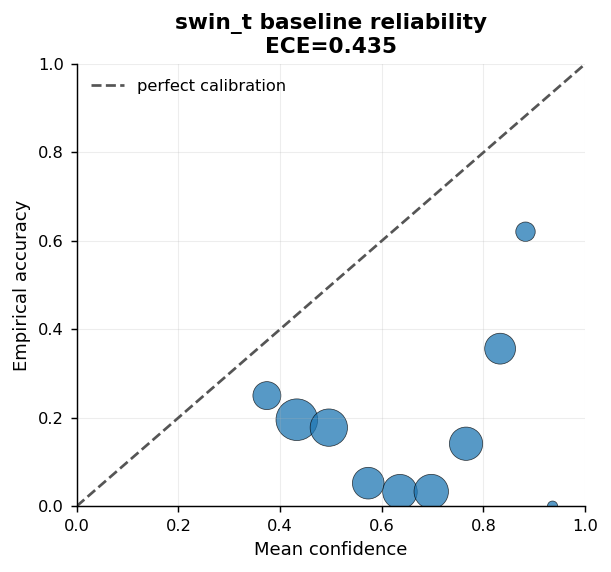

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,kappa,normal_precision,normal_sensitivity,normal_f1,normal_support,...,malignant_precision,malignant_sensitivity,malignant_f1,malignant_support,malignant_specificity,macro_auroc_ovr,macro_auprc,malignant_auprc,ece,brier_multiclass
0,efficientnet_b0,0.820856,0.836484,0.822514,0.821345,0.690970,0.868347,0.824468,0.845839,376,...,0.789474,0.882353,0.833333,68,0.976471,0.920087,0.891686,0.902034,0.096863,0.295672
1,efficientnet_b3,0.859626,0.872324,0.866668,0.859725,0.756314,0.886179,0.869681,0.877852,376,...,0.873239,0.911765,0.892086,68,0.986765,0.950357,0.931813,0.945741,0.113381,0.242105
2,convnext_tiny,0.664439,0.711476,0.643588,0.670163,0.448999,0.792079,0.638298,0.706922,376,...,0.441860,0.838235,0.578680,68,0.894118,0.803249,0.716902,0.728280,0.114985,0.499263
3,swin_t,0.168449,0.377719,0.161427,0.142331,-0.002707,0.633333,0.050532,0.093596,376,...,0.112676,0.941176,0.201258,68,0.258824,0.673740,0.493473,0.459929,0.435366,0.913376


In [10]:
# ============================================================
# 7. Image-only baseline models
# ============================================================
def try_get_default_weights(model_func):
    if not cfg.use_pretrained_torchvision:
        return None
    try:
        # New torchvision API usually has Weights enum accessible from function name.
        return "DEFAULT"
    except Exception:
        return None


def load_torchvision_classifier(name, num_classes=3):
    name = name.lower()
    weights = "DEFAULT" if cfg.use_pretrained_torchvision else None
    try:
        if name == "resnet50":
            model = tv_models.resnet50(weights=weights)
            in_features = model.fc.in_features
            model.fc = nn.Linear(in_features, num_classes)
        elif name == "efficientnet_b0":
            model = tv_models.efficientnet_b0(weights=weights)
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
        elif name == "efficientnet_b3":
            model = tv_models.efficientnet_b3(weights=weights)
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
        elif name == "convnext_tiny":
            model = tv_models.convnext_tiny(weights=weights)
            in_features = model.classifier[-1].in_features
            model.classifier[-1] = nn.Linear(in_features, num_classes)
        elif name == "swin_t":
            model = tv_models.swin_t(weights=weights)
            in_features = model.head.in_features
            model.head = nn.Linear(in_features, num_classes)
        else:
            raise ValueError(f"Unknown model: {name}")
        return model
    except Exception as e:
        print(f"Pretrained load failed for {name}: {e}")
        print("Retrying with random initialization.")
        old = cfg.use_pretrained_torchvision
        cfg.use_pretrained_torchvision = False
        try:
            return load_torchvision_classifier(name, num_classes)
        finally:
            cfg.use_pretrained_torchvision = old


class FocalCELoss(nn.Module):
    def __init__(self, weight=None, gamma=1.5):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()


def move_batch_to_device(batch):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(DEVICE, non_blocking=True)
        else:
            out[k] = v
    return out


def evaluate_image_classifier(model, loader):
    model.eval()
    logits_all, labels_all, paths_all = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="eval", leave=False):
            batch = move_batch_to_device(batch)
            logits = model(batch["image"])
            logits_all.append(logits.detach().cpu().numpy())
            labels_all.append(batch["label"].detach().cpu().numpy())
            paths_all.extend(batch["image_path"])
    logits = np.concatenate(logits_all)
    labels = np.concatenate(labels_all)
    probs = softmax_np(logits)
    return logits, probs, labels, paths_all


def train_image_baseline(model_name):
    model = load_torchvision_classifier(model_name, num_classes=3).to(DEVICE)
    criterion = FocalCELoss(weight=class_weights, gamma=1.5)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, cfg.baseline_epochs))
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp and DEVICE.type == "cuda")

    best_score = -1
    best_path = CKPT_DIR / f"best_{model_name}_baseline.pt"
    history = []

    for epoch in range(1, cfg.baseline_epochs + 1):
        model.train()
        losses = []
        optimizer.zero_grad(set_to_none=True)
        pbar = tqdm(train_loader, desc=f"{model_name} epoch {epoch}/{cfg.baseline_epochs}")
        for step, batch in enumerate(pbar, start=1):
            batch = move_batch_to_device(batch)
            with torch.cuda.amp.autocast(enabled=cfg.amp and DEVICE.type == "cuda"):
                logits = model(batch["image"])
                loss = criterion(logits, batch["label"]) / cfg.grad_accum_steps
            scaler.scale(loss).backward()
            if step % cfg.grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            losses.append(float(loss.detach().cpu()) * cfg.grad_accum_steps)
            pbar.set_postfix(loss=np.mean(losses[-20:]))
        scheduler.step()
        val_logits, val_probs, val_labels, _ = evaluate_image_classifier(model, val_loader)
        metrics = classification_metrics_from_probs(val_probs, val_labels)
        score = journal_score(metrics)
        row = {"model": model_name, "epoch": epoch, "train_loss": np.mean(losses), "journal_score": score, **metrics}
        history.append(row)
        print(f"{model_name} epoch {epoch}: val macro-F1={metrics['macro_f1']:.4f}, malignant sens={metrics['malignant_sensitivity']:.4f}, ECE={metrics['ece']:.4f}, score={score:.4f}")
        if score > best_score:
            best_score = score
            torch.save({"model": model.state_dict(), "cfg": asdict(cfg), "model_name": model_name, "epoch": epoch, "score": score}, best_path)

    # Load best and test.
    ckpt = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model"])
    test_logits, test_probs, test_labels, test_paths = evaluate_image_classifier(model, test_loader)
    test_metrics = classification_metrics_from_probs(test_probs, test_labels)
    history_df = pd.DataFrame(history)
    history_df.to_csv(TABLE_DIR / f"history_{model_name}_baseline.csv", index=False)
    pd.DataFrame({"path": test_paths, "label": test_labels, **{f"prob_{lab}": test_probs[:,i] for i, lab in enumerate(LABEL_ORDER)}}).to_csv(
        PRED_DIR / f"predictions_{model_name}_baseline_test.csv", index=False
    )
    plot_confusion(test_labels, test_probs.argmax(1), f"{model_name} baseline test confusion", f"fig_{model_name}_baseline_confusion.png")
    plot_roc_pr(test_labels, test_probs, f"{model_name} baseline", f"fig_{model_name}_baseline")
    plot_reliability(test_labels, test_probs, f"{model_name} baseline reliability", f"fig_{model_name}_baseline_reliability.png")
    return model, history_df, test_metrics

baseline_rows = []
baseline_models = {}
for model_name in cfg.baseline_models:
    try:
        model, hist, test_metrics = train_image_baseline(model_name)
        baseline_models[model_name] = model
        baseline_rows.append({"model": model_name, **test_metrics})
    except Exception as e:
        print(f"Skipping baseline {model_name} due to error: {e}")

image_baseline_results = pd.DataFrame(baseline_rows)
image_baseline_results.to_csv(TABLE_DIR / "portion2_image_baseline_test_metrics.csv", index=False)
display(image_baseline_results)